# Projeto Final
This notebook downloads the BraTS 2018 and 2020 datasets from Kaggle. Make sure you have accepted the competition rules on Kaggle for these datasets.

## 1. Download dos Datasets

O código a seguir mostra a inserção das credenciais de uma conta no Kaggle para obter os datasets Brats 2018 e Brats 2020.

In [ ]:
import os
from google.colab import userdata

# Securely retrieve Kaggle credentials from Colab Secrets
try:
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
except Exception as e:
    print("Please add KAGGLE_USERNAME and KAGGLE_KEY to your Colab Secrets.")

# Create directory for datasets
!mkdir -p datasets/brats2018 datasets/brats2020

Aqui, é feito o upload dos datasets bem como a sua organização dentro do projeto depois da extração das pastas.

In [ ]:
import os
import glob

def baixar_e_limpar(slug_dataset, diretorio_destino):
    """Baixa um dataset do Kaggle e remove o arquivo zip para economizar espaço."""
    print(f"\n--- Processando {slug_dataset} ---")

    # 1. Download
    !kaggle datasets download -d {slug_dataset} -p {diretorio_destino}

    # 2. Extração
    arquivos_zip = glob.glob(os.path.join(diretorio_destino, "*.zip"))
    if arquivos_zip:
        for caminho_zip in arquivos_zip:
            print(f"Extraindo {caminho_zip}...")
            !unzip -q {caminho_zip} -d {diretorio_destino}
            # 3. Limpeza do zip para economizar espaço em disco
            os.remove(caminho_zip)
            print(f"Removido {caminho_zip} para liberar espaço.")
    else:
        print(f"Nenhum arquivo zip encontrado em {diretorio_destino} (pode já estar extraído).")

# Configuração
BRATS_2018 = "sanglequang/brats2018"
BRATS_2020 = "awsaf49/brats20-dataset-training-validation"

# Execução
if not os.path.exists('datasets/brats2018/MICCAI_BraTS_2018_Data_Training'):
    baixar_e_limpar(BRATS_2018, 'datasets/brats2018')
else:
    print("BraTS 2018 já existe e está extraído.")

if not os.path.exists('datasets/brats2020/BraTS2020_TrainingData'):
    baixar_e_limpar(BRATS_2020, 'datasets/brats2020')
else:
    print("BraTS 2020 já existe e está extraído.")

print("\n Todos os datasets foram processados e limpos.")

BraTS 2018 já existe e está extraído.
BraTS 2020 já existe e está extraído.

 Todos os datasets foram processados e limpos.


## 2. Entendendo o Formato e Modalidades


### Tarefa
Explorar os fundamentos do conjunto de dados BraTS (Brain Tumor Segmentation) analisando o formato de arquivo NIfTI (.nii) e as quatro modalidades de ressonância magnética (T1, T1ce, T2, FLAIR) localizadas em “datasets/brats2018” e “datasets/brats2020”, definir o significado biológico dos rótulos de segmentação (Núcleo do tumor, Tumor com realce e Tumor completo) e investigar técnicas essenciais de pré-processamento de imagens médicas 3D, como normalização por Z-score e correção de campo de desvio, para se preparar para a implementação de uma arquitetura 3D U-Net.
### Ideia:
Explorar o que são arquivos .nii (NIfTI) e por que o BRaTS utiliza quatro modalidades de RM (T1, T1ce, T2, FLAIR).

Aqui é carregado um paciente aleatório de cada dataset (Brats 2018) e (Brats 2020) para mostrar os 4 tipos de ressonância. Foi escolhida a fatia central para ter uma boa visão geral da estrutura cerebral.

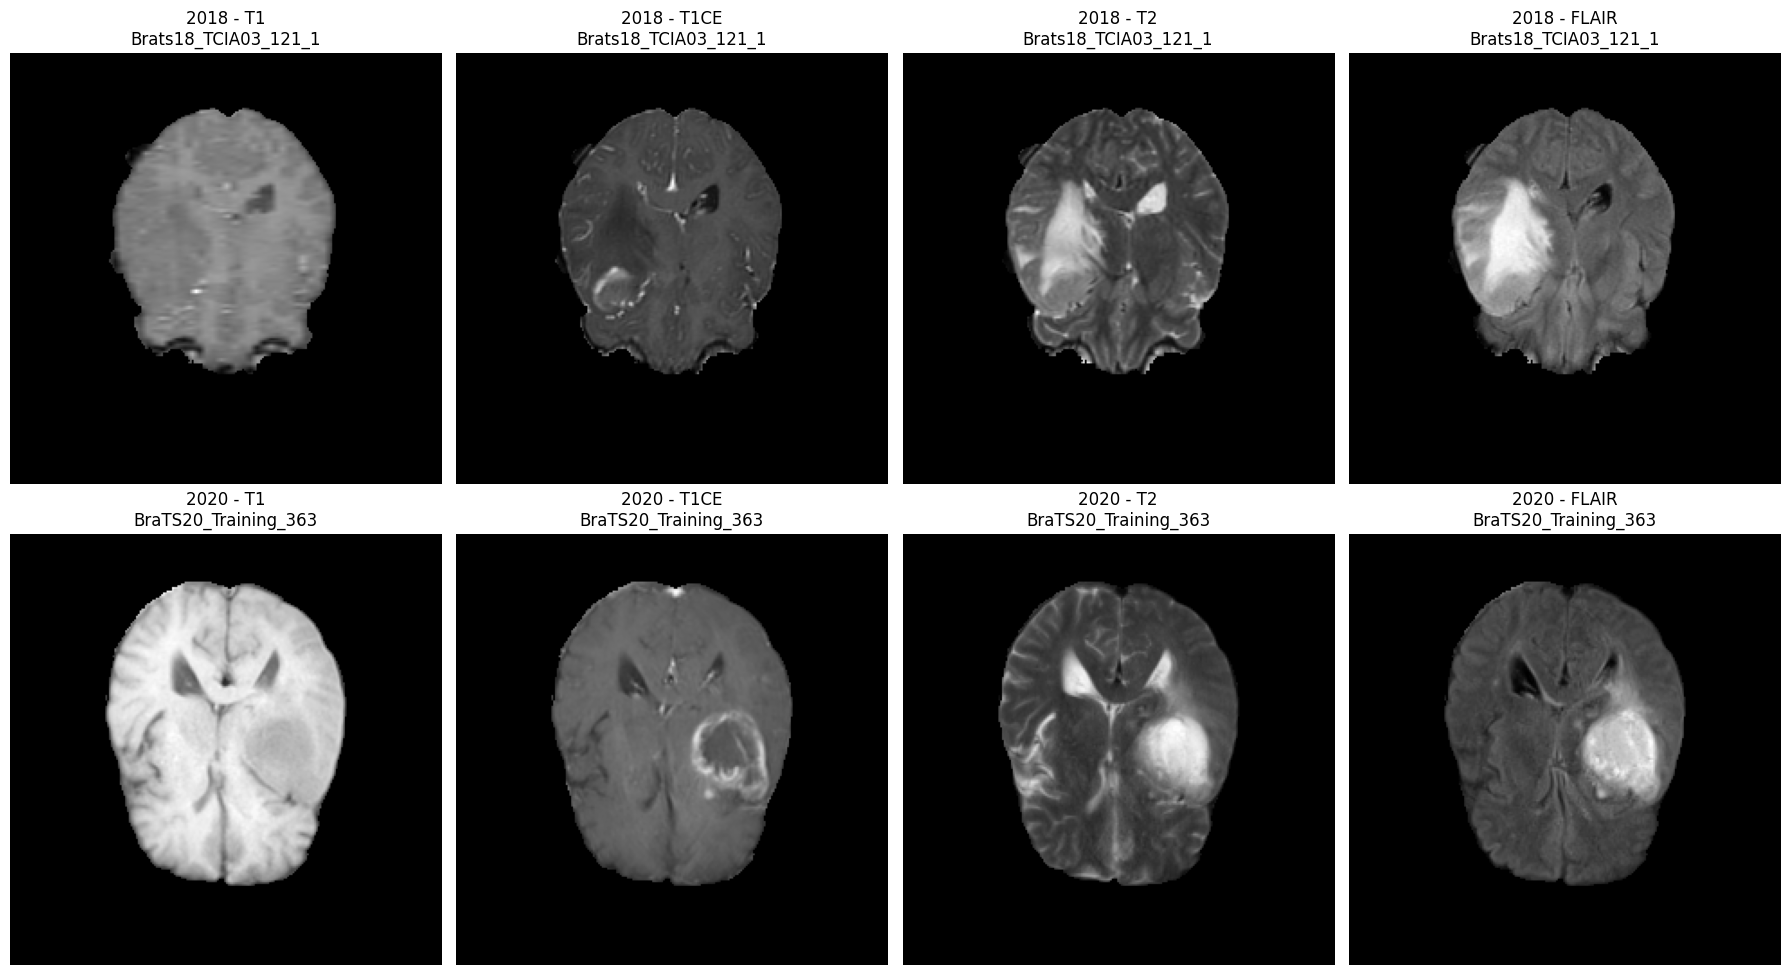

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

# Configuração de Caminhos
diretorio_2018 = 'datasets/brats2018/MICCAI_BraTS_2018_Data_Training/HGG'
pastas_2018 = sorted(glob.glob(os.path.join(diretorio_2018, 'Brats18_*')))

diretorio_2020 = 'datasets/brats2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'
pastas_2020 = sorted(glob.glob(os.path.join(diretorio_2020, 'BraTS20_Training_*')))

def carregar_modalidades(pasta_paciente):
    modalidades = ['t1', 't1ce', 't2', 'flair']
    dados_paciente = {}
    for m in modalidades:
        arquivos = glob.glob(os.path.join(pasta_paciente, f'*{m}.nii*'))
        if arquivos:
            img = nib.load(arquivos[0])
            fatia = img.get_fdata()[:, :, img.shape[2] // 2]
            dados_paciente[m] = np.rot90(fatia)
    return dados_paciente

if pastas_2018 and pastas_2020:
    paciente_18 = np.random.choice(pastas_2018)
    paciente_20 = np.random.choice(pastas_2020)

    imgs_18 = carregar_modalidades(paciente_18)
    imgs_20 = carregar_modalidades(paciente_20)

    # --- Visualização ---
    fig, eixos = plt.subplots(2, 4, figsize=(18, 10))
    modalidades = ['t1', 't1ce', 't2', 'flair']

    for i, m in enumerate(modalidades):
        # Linha 1: BraTS 2018
        if m in imgs_18:
            eixos[0, i].imshow(imgs_18[m], cmap='gray')
            eixos[0, i].set_title(f"2018 - {m.upper()}\n{os.path.basename(paciente_18)}")
            eixos[0, i].axis('off')

        # Linha 2: BraTS 2020
        if m in imgs_20:
            eixos[1, i].imshow(imgs_20[m], cmap='gray')
            eixos[1, i].set_title(f"2020 - {m.upper()}\n{os.path.basename(paciente_20)}")
            eixos[1, i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Erro ao localizar as pastas. Verifique os caminhos dos datasets.")

### 2.1 Inspeção de Dimensões e Voxels
Nesta etapa, vamos verificar como o Python enxerga os volumes 3D.
- **Shape**: Indica (Altura, Largura, Profundidade, Modalidades).
- **Voxels**: São os equivalentes 3D dos pixels.

Aqui, os 2 pacientes sorteados anteriormente tem suas imagens de ressonância e segmentação verificados.

- Shape (H, W, D) → tamanho da imagem 3D: altura, largura e número de fatias

- Intensidade mínima → menor valor encontrado nos voxels

- Intensidade máxima → maior valor encontrado

- Média de intensidade → valor médio dos voxels

- Desvio padrão → mostra o quanto os valores variam na imagem

Os rótulos das máscaras também são mostrados. Nesse caso temos 4. Voxels sem tumor são marcados com (0).

In [ ]:
import nibabel as nib
import glob
import os
import numpy as np

# Verificandteados no bloco anterior existem no ambienteo se os pacientes sor
if 'paciente_18' in locals() and 'paciente_20' in locals():
    pacientes_para_inspecao = [('2018', paciente_18), ('2020', paciente_20)]

    for ano, caminho in pacientes_para_inspecao:
        print(f"=== Analisando BraTS {ano}: {os.path.basename(caminho)} ===\n")

        modalidades = ['t1', 't1ce', 't2', 'flair', 'seg']

        for m in modalidades:
            arquivos = glob.glob(os.path.join(caminho, f'*{m}.nii*'))
            if arquivos:
                img = nib.load(arquivos[0])
                dados = img.get_fdata()

                print(f"Modalidade: {m.upper()}")
                print(f"  - Shape (H, W, D): {dados.shape}")
                print(f"  - Intensidade Mínima: {np.min(dados):.1f}")
                print(f"  - Intensidade Máxima: {np.max(dados):.1f}")
                print(f"  - Média de Intensidade: {np.mean(dados):.1f}")
                print(f"  - Desvio Padrão de Intensidade: {np.std(dados):.1f}")

                if m == 'seg':
                    print(f"  - Labels únicos: {np.unique(dados)}")
                print("-" * 30)
        print("\n" + "="*50 + "\n")
else:
    print("Erro: Execute o bloco de visualização acima primeiro para sortear os pacientes.")

=== Analisando BraTS 2018: Brats18_TCIA03_121_1 ===

Modalidade: T1
  - Shape (H, W, D): (240, 240, 155)
  - Intensidade Mínima: 0.0
  - Intensidade Máxima: 1148.0
  - Média de Intensidade: 44.2
  - Desvio Padrão de Intensidade: 115.1
------------------------------
Modalidade: T1CE
  - Shape (H, W, D): (240, 240, 155)
  - Intensidade Mínima: 0.0
  - Intensidade Máxima: 576.0
  - Média de Intensidade: 14.0
  - Desvio Padrão de Intensidade: 37.1
------------------------------
Modalidade: T2
  - Shape (H, W, D): (240, 240, 155)
  - Intensidade Mínima: 0.0
  - Intensidade Máxima: 959.0
  - Média de Intensidade: 35.7
  - Desvio Padrão de Intensidade: 99.9
------------------------------
Modalidade: FLAIR
  - Shape (H, W, D): (240, 240, 155)
  - Intensidade Mínima: 0.0
  - Intensidade Máxima: 501.0
  - Média de Intensidade: 24.1
  - Desvio Padrão de Intensidade: 65.5
------------------------------
Modalidade: SEG
  - Shape (H, W, D): (240, 240, 155)
  - Intensidade Mínima: 0.0
  - Intensidade

## 3. Préprocessamento


### 3.1 Correção de Iluminação de Fundo (N4 Bias Field Correction) OPCIONAL
**Objetivo:** Remover gradientes artificiais de intensidade causados por imperfeições no campo magnético do aparelho de ressonância no momento do exame.
**Justificativa Analítica:** Imperfeições no campo magnético geram artefatos onde um hemisfério do cérebro aparece artificialmente mais claro que o outro. Redes neurais podem aprender esses gradientes erradamente. O algoritmo N4 estima e subtrai esse campo de viés, homogeneizando o tecido. Aplicaremos isso na modalidade T1 do paciente de 2020.
*(Nota: Instalar biblioteca executando `!pip install SimpleITK` na célula anterior se necessário)*

Esse código pega o exame T1 inteiro em 3D de um paciente do BraTS 2020 e tenta corrigir uma imperfeição comum da ressonância chamada viés de campo magnético.

Às vezes, em uma ressonância, uma região do cérebro pode parecer mais clara ou mais escura apenas por causa do aparelho, mesmo sendo o mesmo tipo de tecido.

É como se a imagem tivesse uma iluminação desigual:

Mesmo tecido cerebral
lado esquerdo → parece mais escuro
lado direito  → parece mais claro

Isso pode confundir um modelo de IA, porque ele pode interpretar essa diferença artificial como algo importante, como um tumor ou alteração no tecido.

O filtro N4 Bias Correction tenta remover essa diferença artificial de brilho.

- Diferença próxima de 0 → quase nada mudou

- Diferença alta         → N4 corrigiu bastante aquela região

- Diferença negativa     → N4 aumentou a intensidade naquele ponto

- Diferença positiva     → N4 diminuiu a intensidade naquele ponto


In [ ]:
!pip install SimpleITK

Aplicando N4 Bias Correction no paciente BraTS20_Training_363...
Isto pode demorar cerca de 10 a 30 segundos dependendo da CPU do Colab.


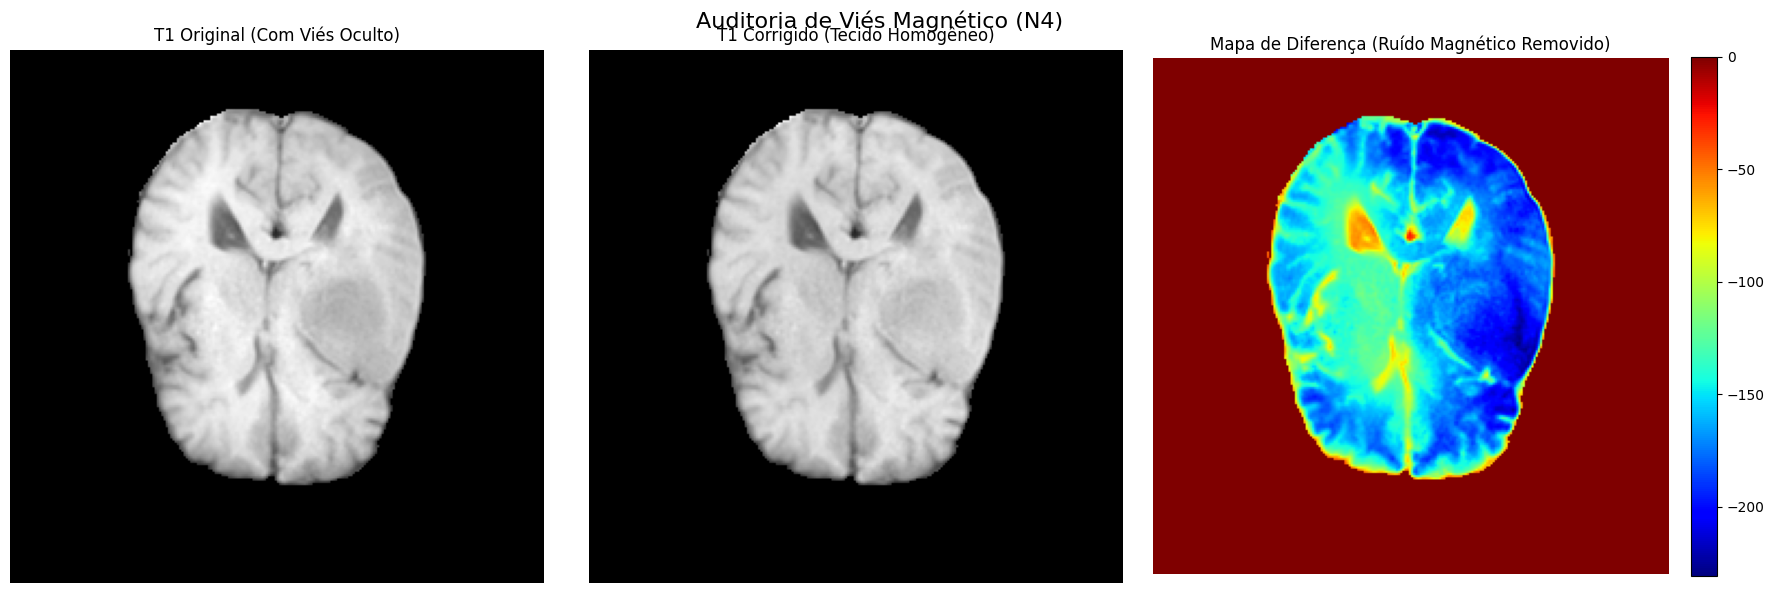

In [ ]:
import SimpleITK as sitk

# Carregando o volume 3D INTEIRO do T1 do paciente BraTS 2020
arquivo_t1 = glob.glob(os.path.join(paciente_20, '*t1.nii*'))[0]
volume_t1_bruto = nib.load(arquivo_t1).get_fdata()

def aplicar_correcao_n4(volume_numpy):
    # O SimpleITK trabalha com o seu próprio formato de imagem
    sitk_image = sitk.GetImageFromArray(volume_numpy.astype(np.float32))

    # Criar uma máscara para focar o cálculo do N4 apenas no cérebro (otimiza o tempo computacional)
    mask_image = sitk.OtsuThreshold(sitk_image, 0, 1, 200)

    # Aplicar o Filtro N4
    n4_filter = sitk.N4BiasFieldCorrectionImageFilter()
    corrected_image = n4_filter.Execute(sitk_image, mask_image)

    return sitk.GetArrayFromImage(corrected_image)

def aplicar_n4_otimizado(volume_numpy):
    """
    Versão otimizada do N4: Encolhe a imagem em 4x para calcular o viés magnético,
    derrubando o tempo de processamento de minutos para segundos.
    """
    # 1. Converter para SimpleITK
    sitk_image = sitk.GetImageFromArray(volume_numpy.astype(np.float32))

    # 2. Criar a máscara na imagem original
    mask_image = sitk.OtsuThreshold(sitk_image, 0, 1, 200)

    # 3.  Encolher a imagem e a máscara em 4x (fator 4)
    shrink_factor = 4
    shrunk_image = sitk.Shrink(sitk_image, [shrink_factor]*sitk_image.GetDimension())
    shrunk_mask = sitk.Shrink(mask_image, [shrink_factor]*sitk_image.GetDimension())

    # 4. Calcular o N4 na imagem PEQUENA
    n4_filter = sitk.N4BiasFieldCorrectionImageFilter()
    # Retorna a imagem pequena corrigida (mas não a queremos, queremos o campo gerado)
    n4_filter.Execute(shrunk_image, shrunk_mask)

    # 5. Extrair o campo de log-bias calculado e aplicar na imagem de tamanho ORIGINAL
    log_bias_field = n4_filter.GetLogBiasFieldAsImage(sitk_image)

    # A matemática reversa do N4: Imagem Corrigida = Imagem Original / exp(LogBias)
    corrected_image_sitk = sitk_image / sitk.Exp(log_bias_field)

    return sitk.GetArrayFromImage(corrected_image_sitk)

print(f"Aplicando N4 Bias Correction no paciente {os.path.basename(paciente_20)}...")
print("Isto pode demorar cerca de 10 a 30 segundos dependendo da CPU do Colab.")
volume_t1_corrigido = aplicar_n4_otimizado(volume_t1_bruto)

# --- Visualização Analítica (Fatia Central vs. Fatia Corrigida vs. Mapa de Viés) ---
fatia_z = volume_t1_bruto.shape[2] // 2
img_original = np.rot90(volume_t1_bruto[:, :, fatia_z])
img_corrigida = np.rot90(volume_t1_corrigido[:, :, fatia_z])

# Subtrair a imagem corrigida da original revela o campo magnético irregular que estava oculto
mapa_diferenca = img_original - img_corrigida

fig, eixos = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Auditoria de Viés Magnético (N4)", fontsize=16)

eixos[0].imshow(img_original, cmap='gray')
eixos[0].set_title("T1 Original (Com Viés Oculto)")

eixos[1].imshow(img_corrigida, cmap='gray')
eixos[1].set_title("T1 Corrigido (Tecido Homogêneo)")

im3 = eixos[2].imshow(mapa_diferenca, cmap='jet')
eixos[2].set_title("Mapa de Diferença (Ruído Magnético Removido)")
plt.colorbar(im3, ax=eixos[2], fraction=0.046, pad=0.04)

for ax in eixos:
    ax.axis('off')

plt.tight_layout()
plt.show()

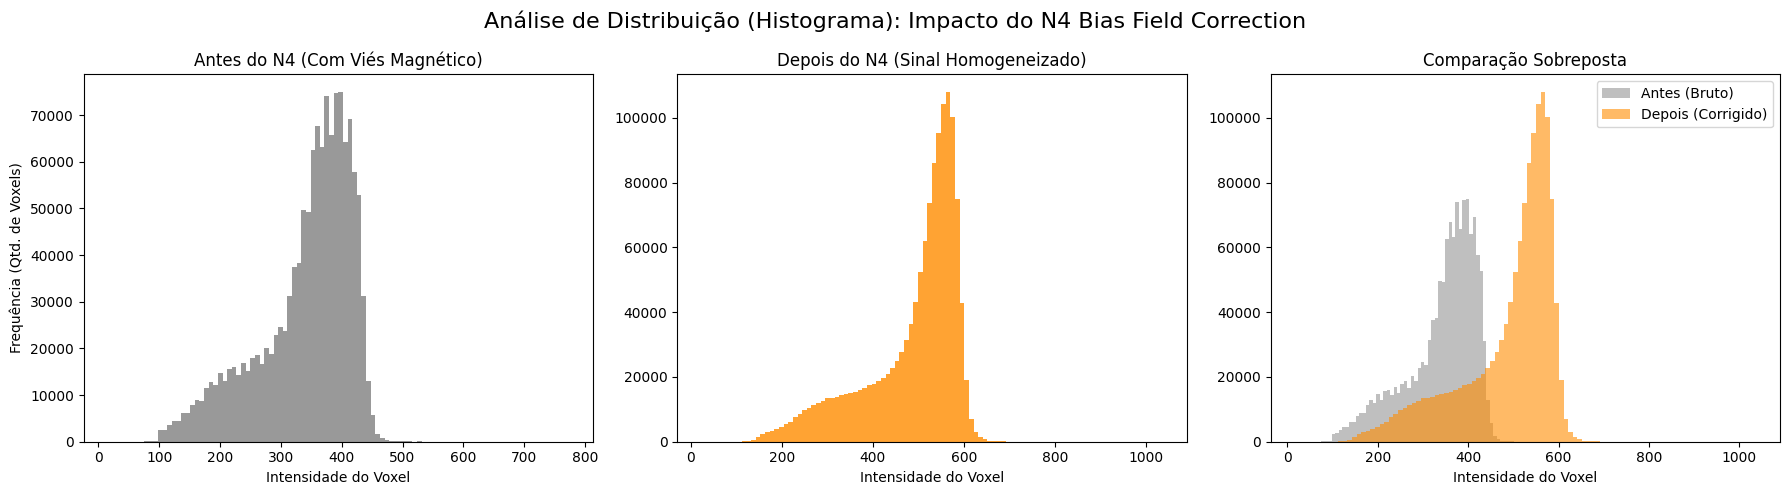

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Criar uma máscara para analisar apenas o tecido cerebral (ignorando o ar/fundo = 0)
mask = volume_t1_bruto > 0
pixels_brutos = volume_t1_bruto[mask]
pixels_corrigidos = volume_t1_corrigido[mask]

fig, eixos = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Análise de Distribuição (Histograma): Impacto do N4 Bias Field Correction", fontsize=16)

# 1. Histograma ANTES do N4
eixos[0].hist(pixels_brutos.flatten(), bins=100, color='gray', alpha=0.8)
eixos[0].set_title("Antes do N4 (Com Viés Magnético)")
eixos[0].set_xlabel("Intensidade do Voxel")
eixos[0].set_ylabel("Frequência (Qtd. de Voxels)")

# 2. Histograma DEPOIS do N4
eixos[1].hist(pixels_corrigidos.flatten(), bins=100, color='darkorange', alpha=0.8)
eixos[1].set_title("Depois do N4 (Sinal Homogeneizado)")
eixos[1].set_xlabel("Intensidade do Voxel")

# 3. Sobreposição para comparação direta
eixos[2].hist(pixels_brutos.flatten(), bins=100, color='gray', alpha=0.5, label='Antes (Bruto)')
eixos[2].hist(pixels_corrigidos.flatten(), bins=100, color='darkorange', alpha=0.6, label='Depois (Corrigido)')
eixos[2].set_title("Comparação Sobreposta")
eixos[2].set_xlabel("Intensidade do Voxel")
eixos[2].legend()

plt.tight_layout()
plt.show()


**Análise do Histograma:**
Note que no gráfico sobreposto, a distribuição original costuma ser mais "espalhada" ou apresentar múltiplos picos anormais devido à iluminação desigual. A correção N4 tende a condensar os valores de tecidos semelhantes num mesmo intervalo de intensidade, criando picos mais finos e definidos, o que facilita enormemente o trabalho da rede neural ao interpretar os tons de cinza.

### 3.2 Normalização de Intensidade (Brain-Only Z-Score)
Vamos padronizar a escala de intensidade dos *voxels* para garantir que a rede neural receba dados com a mesma distribuição estatística, independentemente do scanner.

O objetivo aqui é isolar o tecido cerebral do fundo da imagem (ar) para calcular estatísticas precisas. A função cria uma máscara booleana (volume > 0).

Ao invés de aplicar a fórmula clássica $z = \frac{x - \mu}{\sigma}$ em todos os milhões de voxels, nós extraímos apenas os pixels verdadeiros (o cérebro) para calcular a média ($\mu$) e o desvio padrão ($\sigma$).

Ao final, inicializamos um volume zerado e injetamos os valores calculados apenas onde havia cérebro. Nesta nova versão analítica, o código vai plotar a diferença de distribuição antes e depois para as quatro modalidades ao mesmo tempo.

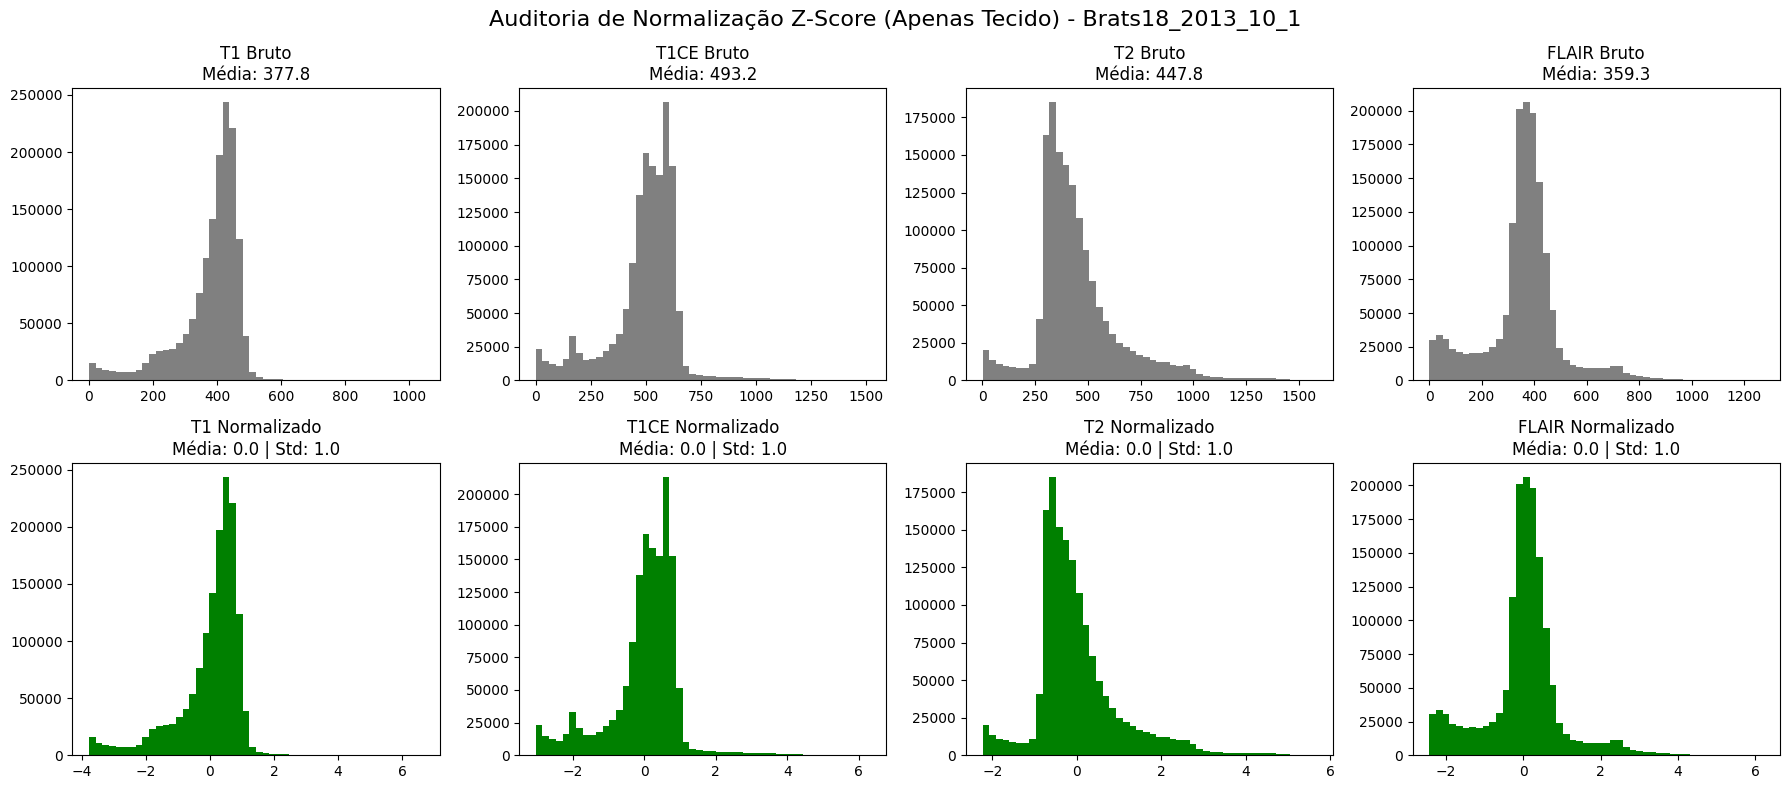

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

paciente_alvo = pastas_2018[0] # Fixo no primeiro para reprodutibilidade
nome_paciente = os.path.basename(paciente_alvo)

# A Função de Controle de Qualidade Estatística
def brain_only_zscore_normalize(volume):
    brain_mask = volume > 0
    if not np.any(brain_mask):
        return volume

    brain_pixels = volume[brain_mask]
    mean_val = np.mean(brain_pixels)
    std_val = np.std(brain_pixels)

    normalized_volume = np.zeros_like(volume, dtype=np.float32)
    # 1e-8 evita divisão por zero caso o desvio padrão seja nulo
    normalized_volume[brain_mask] = (volume[brain_mask] - mean_val) / (std_val + 1e-8)
    return normalized_volume

# Carregamento e Análise de Todas as Modalidades
modalidades = ['t1', 't1ce', 't2', 'flair']
volumes_brutos = {}
volumes_norm = {}

for m in modalidades:
    arquivo = glob.glob(os.path.join(paciente_alvo, f'*{m}.nii*'))[0]
    vol = nib.load(arquivo).get_fdata()
    volumes_brutos[m] = vol
    volumes_norm[m] = brain_only_zscore_normalize(vol)

# --- HISTOGRAMAS ---
fig, eixos = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(f"Auditoria de Normalização Z-Score (Apenas Tecido) - {nome_paciente}", fontsize=16)

for i, m in enumerate(modalidades):
    # Extrair apenas os pixels do cérebro para o plot
    pixels_brutos = volumes_brutos[m][volumes_brutos[m] > 0]
    pixels_norm = volumes_norm[m][volumes_brutos[m] > 0]

    eixos[0, i].hist(pixels_brutos.flatten(), bins=50, color='gray')
    eixos[0, i].set_title(f"{m.upper()} Bruto\nMédia: {np.mean(pixels_brutos):.1f}")

    eixos[1, i].hist(pixels_norm.flatten(), bins=50, color='green')
    eixos[1, i].set_title(f"{m.upper()} Normalizado\nMédia: 0.0 | Std: 1.0")

plt.tight_layout()
plt.show()

### 3.3 Desconstrução Lógica do Ground Truth (Máscara)

O BraTS entrega uma máscara unificada onde diferentes valores inteiros representam diferentes partes do tumor. Se passássemos isso direto para a rede, ela tentaria criar uma relação matemática falsa (achando que a classe 4 é matematicamente maior/mais importante que a classe 1).

A função processar_mascara_brats resolve isso aplicando portas lógicas (np.logical_or). Ela varre a matriz procurando padrões específicos para construir três alvos binários isolados:

WT (Whole Tumor): Tudo o que é doença (Rótulos 1, 2 ou 4).

TC (Tumor Core): A massa sólida excluindo o edema (Rótulos 1 ou 4).

ET (Enhancing Tumor): Apenas a margem ativa (Rótulo 4).

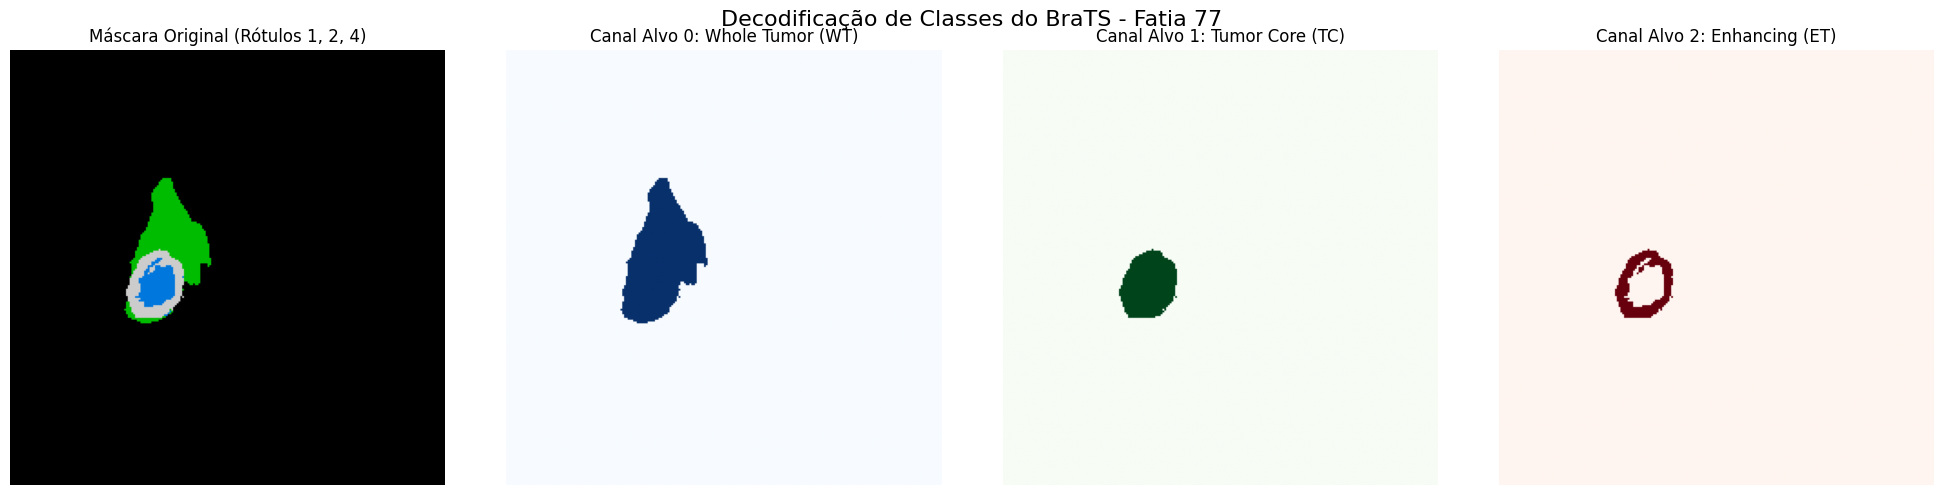

In [ ]:
def processar_mascara_brats(mask_volume):
    WT = np.logical_or.reduce((mask_volume == 1, mask_volume == 2, mask_volume == 4))
    TC = np.logical_or(mask_volume == 1, mask_volume == 4)
    ET = (mask_volume == 4)

    # Empilha no eixo de profundidade/canais (axis=-1)
    return np.stack([WT, TC, ET], axis=-1).astype(np.float32)

# Carregar a máscara
arquivo_mask = glob.glob(os.path.join(paciente_alvo, '*seg.nii*'))[0]
mask_bruta = nib.load(arquivo_mask).get_fdata()
mask_processada = processar_mascara_brats(mask_bruta)

# --- DESCONSTRUÇÃO DA MÁSCARA ---
fatia_z = mask_bruta.shape[2] // 2

fig, eixos = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f"Decodificação de Classes do BraTS - Fatia {fatia_z}", fontsize=16)

# Máscara Original (Multiclasse)
eixos[0].imshow(np.rot90(mask_bruta[:, :, fatia_z]), cmap='nipy_spectral')
eixos[0].set_title("Máscara Original (Rótulos 1, 2, 4)")

# Máscaras Separadas (Binárias)
classes = ['Whole Tumor (WT)', 'Tumor Core (TC)', 'Enhancing (ET)']
cores = ['Blues', 'Greens', 'Reds']

for i in range(3):
    eixos[i+1].imshow(np.rot90(mask_processada[:, :, fatia_z, i]), cmap=cores[i])
    eixos[i+1].set_title(f"Canal Alvo {i}: {classes[i]}")

for ax in eixos:
    ax.axis('off')

plt.tight_layout()
plt.show()

### 3.4 Construção do Tensor Final e Validação (Channel Stacking)
Com as imagens normalizadas e a máscara desmembrada, este passo simula o exato momento em que os tensores são injetados na rede neural. Utilizamos o np.stack(volumes_normalizados, axis=-1) para colar as quatro matrizes 3D umas contra as outras. O resultado é um único super-tensor geométrico onde o último eixo guarda a "cor" (ou modalidade) do voxel.


--- AUDITORIA DE TENSORES FINAIS ---
Formato do Input (X): (240, 240, 155, 4) -> (Altura, Largura, Fatias, 4 Modalidades)
Formato da Label (Y): (240, 240, 155, 3) -> (Altura, Largura, Fatias, 3 Classes Alvo)


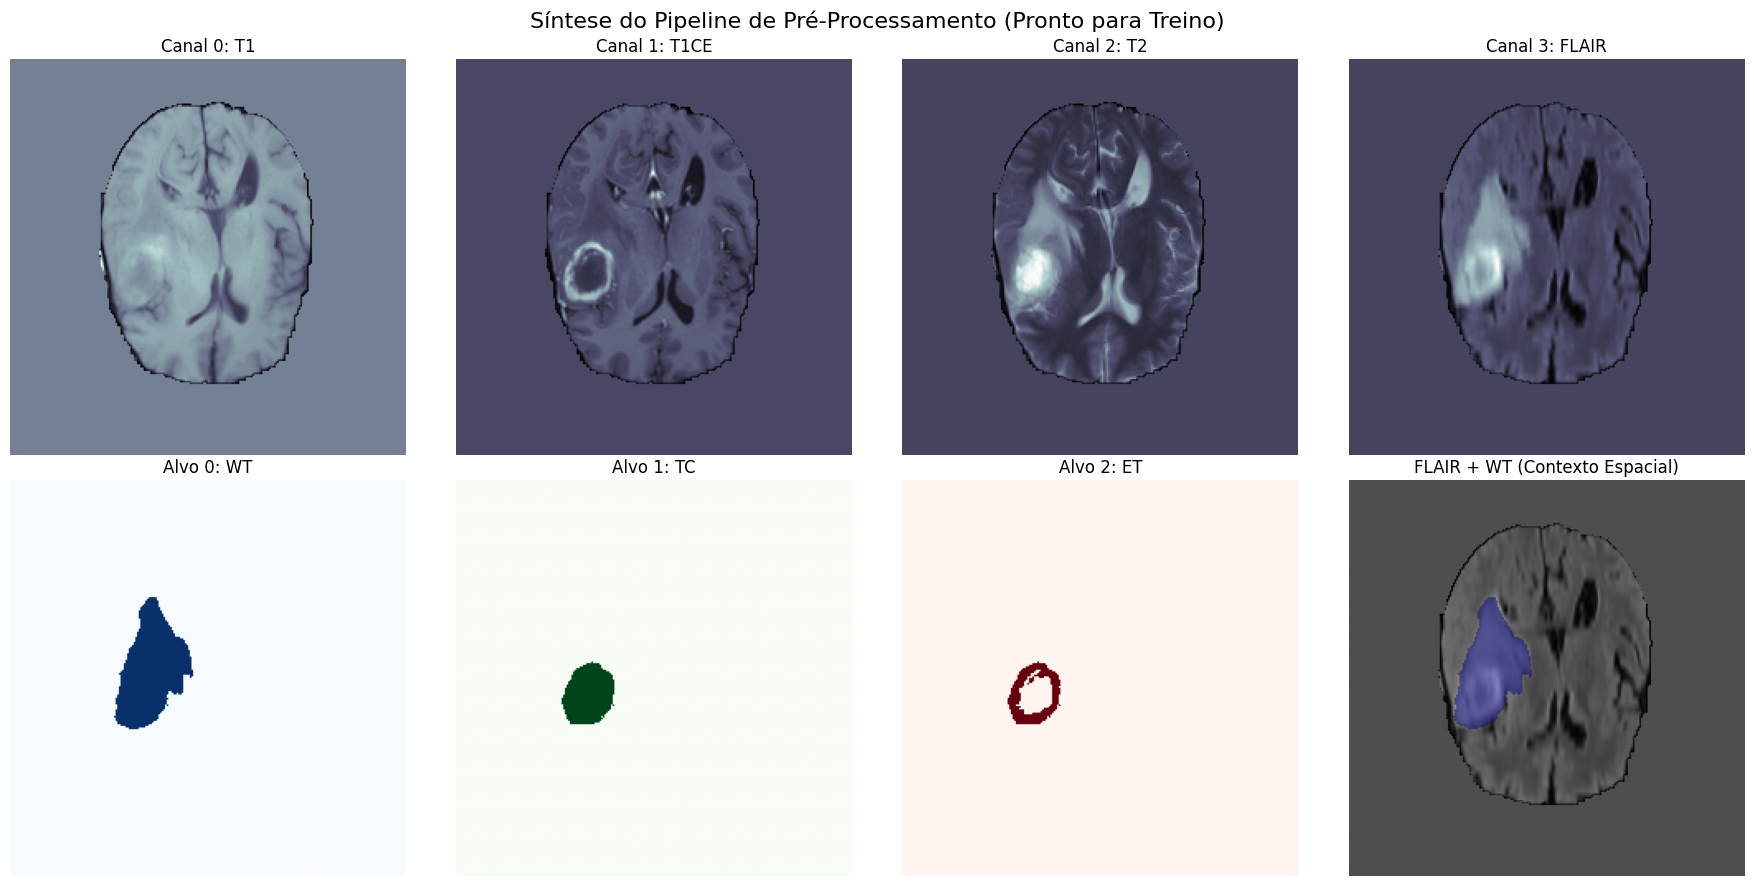

In [ ]:
# Lista na ordem exata: T1, T1CE, T2, FLAIR
lista_volumes = [volumes_norm['t1'], volumes_norm['t1ce'], volumes_norm['t2'], volumes_norm['flair']]
X_tensor = np.stack(lista_volumes, axis=-1)

# O Y_tensor já está pronto do bloco anterior (mask_processada)
Y_tensor = mask_processada

print("--- AUDITORIA DE TENSORES FINAIS ---")
print(f"Formato do Input (X): {X_tensor.shape} -> (Altura, Largura, Fatias, 4 Modalidades)")
print(f"Formato da Label (Y): {Y_tensor.shape} -> (Altura, Largura, Fatias, 3 Classes Alvo)")

# --- VISUALIZAÇÃO FINAL: O QUE A REDE VAI LER ---
# Plot da grade 2x4 similar à sua lógica original, extraindo do Tensor Final
fatia_z = X_tensor.shape[2] // 2
X_slice = np.rot90(X_tensor[:, :, fatia_z, :])
Y_slice = np.rot90(Y_tensor[:, :, fatia_z, :])

fig, eixos = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Síntese do Pipeline de Pré-Processamento (Pronto para Treino)", fontsize=16)

# Linha 1: Extraindo os canais do X_tensor
nomes_x = ['Canal 0: T1', 'Canal 1: T1CE', 'Canal 2: T2', 'Canal 3: FLAIR']
for i in range(4):
    eixos[0, i].imshow(X_slice[:, :, i], cmap='bone')
    eixos[0, i].set_title(nomes_x[i])
    eixos[0, i].axis('off')

# Linha 2: Extraindo os canais do Y_tensor
nomes_y = ['Alvo 0: WT', 'Alvo 1: TC', 'Alvo 2: ET']
for i in range(3):
    eixos[1, i].imshow(Y_slice[:, :, i], cmap=cores[i])
    eixos[1, i].set_title(nomes_y[i])
    eixos[1, i].axis('off')

# Visão combinada no último plot
eixos[1, 3].imshow(X_slice[:, :, 3], cmap='gray') # Fundo FLAIR
eixos[1, 3].imshow(np.ma.masked_where(Y_slice[:, :, 0] == 0, Y_slice[:, :, 0]), cmap='jet', alpha=0.5)
eixos[1, 3].set_title("FLAIR + WT (Contexto Espacial)")
eixos[1, 3].axis('off')

plt.tight_layout()
plt.show()

Esse código junta os dados que entram no modelo com o gabarito que ele deve aprender.

Ele cria duas estruturas:

- X_tensor → as 4 ressonâncias do paciente

- Y_tensor → as 3 máscaras corretas vindas do SEG

Na prática:

- X_tensor:
[T1, T1CE, T2, FLAIR]

- Y_tensor:
[WT, TC, ET]

As quatro ressonâncias não são somadas. Elas ficam empilhadas como quatro canais diferentes:

Canal 0 → T1

Canal 1 → T1CE

Canal 2 → T2

Canal 3 → FLAIR


## 4. Otimização Espacial e Data Augmentation
Para evitar o *overfitting* (memorização dos pacientes) e acelerar o treinamento, implementamos duas técnicas dinâmicas:
1. **Recorte Anatômico (Cropping):** Reduzimos a imagem de $240 \times 240$ para $160 \times 192$, eliminando o fundo preto excessivo (ar) em torno do crânio. Isso poupa memória.
2. **Augmentation On-the-Fly:** Aplicamos transformações estocásticas (espelhamento com 50% de probabilidade e injeção de ruído Gaussiano) durante a geração dos lotes. Isso força o modelo a generalizar a biologia do tumor.

Primeiro, é feito um recorte do cérebro retirando o fundo preto das imagens com a função `recortar_centro_cerebro(...) `.

Com a função `aplicar_aumento_lote(...)` cria-se pequenas variações artificiais nos dados para o modelo não decorar apenas as imagens originais.

A função `visualizar_efeitos_aumento(...)` cria um gráfico para você enxergar os efeitos do aumento de dados.

- Recorte → remove fundo preto desnecessário.

- Espelhamento → cria novas versões da imagem e da máscara.

- Ruído → deixa a ressonância um pouco diferente para o modelo ficar mais resistente.

- Máscara → acompanha os espelhamentos, mas não recebe ruído.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import torch

def recortar_centro_cerebro(volume_4d, mascara_4d, novo_tamanho=(160, 192)):
    """ Remove o fundo preto excessivo. Espera formato (C, Z, Y, X). """
    _, prof, alt_orig, larg_orig = volume_4d.shape
    alt_nova, larg_nova = novo_tamanho

    inicio_y = (alt_orig - alt_nova) // 2
    inicio_x = (larg_orig - larg_nova) // 2
    fim_y = inicio_y + alt_nova
    fim_x = inicio_x + larg_nova

    volume_recortado = volume_4d[:, :, inicio_y:fim_y, inicio_x:fim_x]
    mascara_recortada = mascara_4d[:, :, inicio_y:fim_y, inicio_x:fim_x]

    return volume_recortado, mascara_recortada

def aplicar_aumento_lote(lote_X, lote_Y):
    """ Aplica espelhamento e ruído aleatório no lote. """
    if random.random() > 0.5:
        lote_X = np.flip(lote_X, axis=-1)
        lote_Y = np.flip(lote_Y, axis=-1)

    if random.random() > 0.5:
        lote_X = np.flip(lote_X, axis=-2)
        lote_Y = np.flip(lote_Y, axis=-2)

    if random.random() > 0.7:
        ruido = np.random.normal(loc=0.0, scale=0.05, size=lote_X.shape)
        lote_X = lote_X + ruido

    return lote_X.copy(), lote_Y.copy()

def visualizar_efeitos_aumento(fatia_X, fatia_Y):
    """ Gera o gráfico comparativo perfeito para o Relatório. """
    # 1. Copiamos e alinhamos a rotação de TODOS os canais de uma vez
    # k=1 gira em 90 graus. O cérebro ficará em pé.
    base_X_rot = np.rot90(fatia_X.copy(), k=1, axes=(-2, -1))
    base_Y_rot = np.rot90(fatia_Y.copy(), k=1, axes=(-2, -1))

    # 2. Expandimos para simular o formato de Lote (1, Canais, Y, X)
    lote_X = np.expand_dims(base_X_rot, axis=0)
    lote_Y = np.expand_dims(base_Y_rot, axis=0)

    # 3. Transformações com .copy() para garantir que não se sobrepõem na RAM
    lote_flip_X = np.flip(lote_X, axis=-1).copy() # axis=-1 agora é a largura visual real
    lote_flip_Y = np.flip(lote_Y, axis=-1).copy()

    lote_ruido_X = lote_X + np.random.normal(0, 0.2, size=lote_X.shape)

    # 4. Plotagem
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    canal_visual_x, canal_visual_y = 1, 0 # T1CE e Whole Tumor

    # --- Linha 1 ---
    axes[0, 0].imshow(lote_X[0, canal_visual_x], cmap='gray')
    axes[0, 0].set_title('Original (T1CE)')

    axes[0, 1].imshow(lote_flip_X[0, canal_visual_x], cmap='gray')
    axes[0, 1].set_title('Espelhamento Horizontal')

    axes[0, 2].imshow(lote_ruido_X[0, canal_visual_x], cmap='gray')
    axes[0, 2].set_title('Injeção de Ruído Gaussiano')

    # --- Linha 2 ---
    axes[1, 0].imshow(lote_Y[0, canal_visual_y], cmap='magma')
    axes[1, 0].set_title('Máscara Original (WT)')

    axes[1, 1].imshow(lote_flip_Y[0, canal_visual_y], cmap='magma')
    axes[1, 1].set_title('Máscara Espelhada (WT)')

    axes[1, 2].axis('off')
    axes[1, 2].text(0.5, 0.5, 'Ruído NÃO é aplicado\nna Máscara (Ground Truth)',
                    ha='center', va='center', fontsize=12, fontweight='bold', color='red')

    for ax in axes.flatten():
        if ax != axes[1, 2]: ax.axis('off')

    plt.tight_layout()
    plt.show()

### 4.1 Alinhamento de Eixos (Padrão PyTorch)
O carregamento bruto das imagens do BraTS gera tensores com a profundidade e os canais nas posições finais. No entanto, o PyTorch e a arquitetura ACU-Net exigem estritamente o formato `(Canais, Profundidade, Altura, Largura)`.

Nesta etapa, verificamos a estrutura geométrica do dado e aplicamos uma transposição de eixos (`np.transpose`) para garantir compatibilidade matricial antes de enviar os dados para a GPU.

In [ ]:
print(f"Shape original do X_tensor: {X_tensor.shape}")

# O seu shape atual é (240, 240, 155, Canais)
# O modelo exige (Canais, Z, Y, X) -> (4, 155, 240, 240)

if X_tensor.shape == (240, 240, 155, 4):
    # Transpõe movendo o eixo 3 (Canais) para a posição 0, e o eixo 2 (Z) para a posição 1
    X_tensor_alinhado = np.transpose(X_tensor, (3, 2, 0, 1))

    # Fazemos o mesmo para a máscara (que tem 3 canais)
    Y_tensor_alinhado = np.transpose(Y_tensor, (3, 2, 0, 1))
    print("Sucesso: Eixos transpostos para o padrão PyTorch!")
else:
    # Se você rodar a célula duas vezes, ele não estraga o que já foi consertado
    X_tensor_alinhado = X_tensor
    Y_tensor_alinhado = Y_tensor
    print("Os eixos já estão no padrão PyTorch.")

print(f"Novo shape X: {X_tensor_alinhado.shape} | Esperado: (4, 155, 240, 240)")
print(f"Novo shape Y: {Y_tensor_alinhado.shape} | Esperado: (3, 155, 240, 240)")

Shape original do X_tensor: (240, 240, 155, 4)
Sucesso: Eixos transpostos para o padrão PyTorch!
Novo shape X: (4, 155, 240, 240) | Esperado: (4, 155, 240, 240)
Novo shape Y: (3, 155, 240, 240) | Esperado: (3, 155, 240, 240)


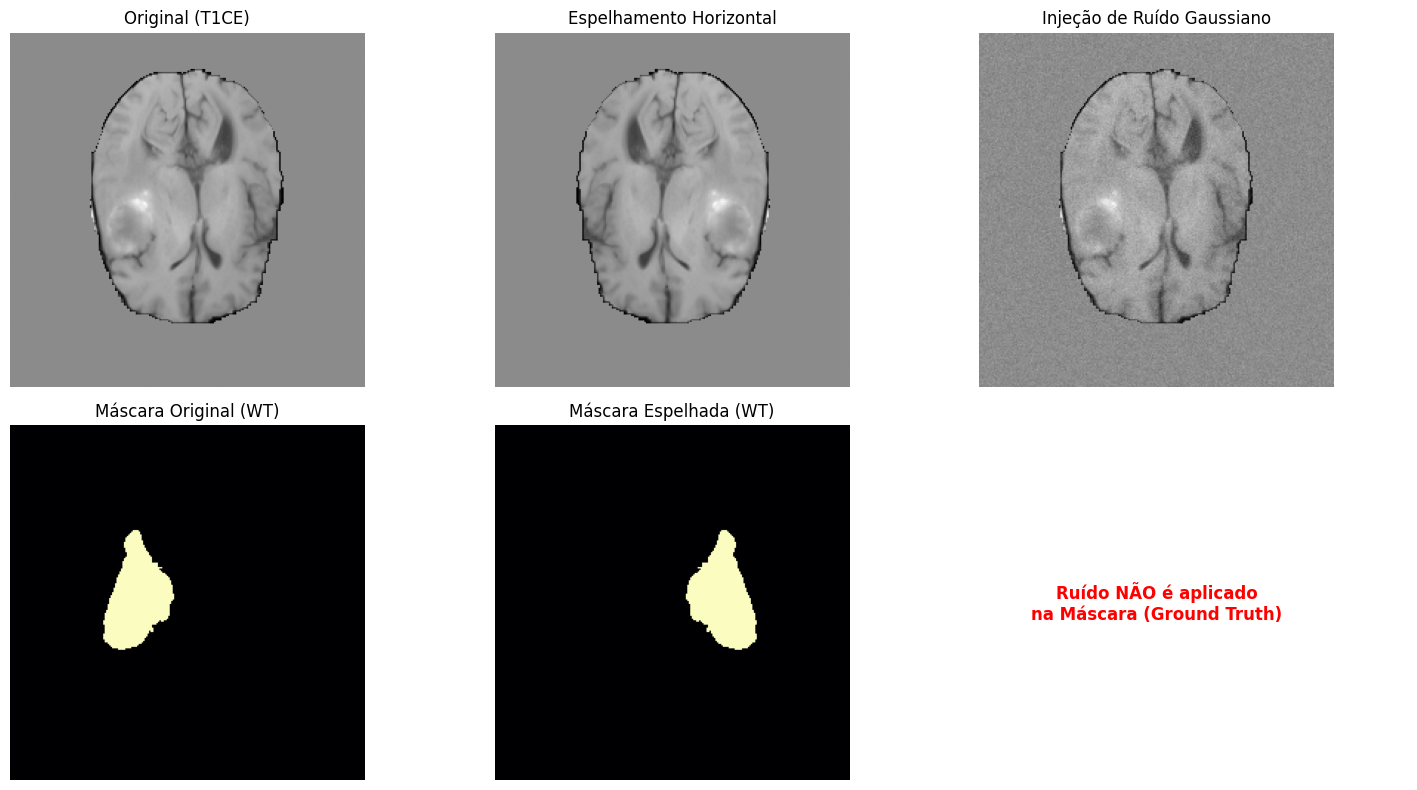

In [ ]:
fatia_z = 75

# Agora que a profundidade está na posição certa (eixo 1), o fatiamento vai funcionar
bloco_real_x = X_tensor_alinhado[:, fatia_z-1:fatia_z+2, :, :]

# O reshape agora vai pegar (4 canais x 3 fatias) e transformar em 12, sem erro!
bloco_real_x = bloco_real_x.reshape(-1, 240, 240)

# A máscara extrai a fatia central
bloco_real_y = Y_tensor_alinhado[:, fatia_z, :, :]

# Plota a prova visual
visualizar_efeitos_aumento(bloco_real_x, bloco_real_y)

Gerando comparativo de Recorte Anatômico...


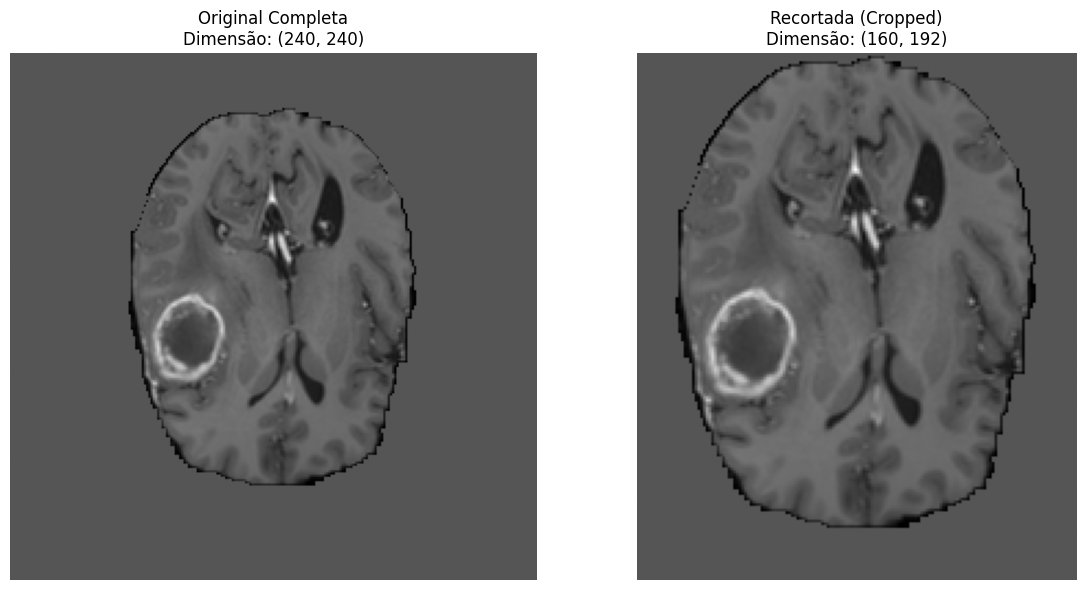

In [ ]:
# ==========================================
# BLOCO EXTRA: VISUALIZAÇÃO DO RECORTE (CROPPING)
# ==========================================
print("Gerando comparativo de Recorte Anatômico...")

fatia_z = 75
canal_visual = 1 # Canal T1CE

# 1. Extraímos a fatia do tensor original (240x240)
fatia_original = X_tensor_alinhado[canal_visual, fatia_z, :, :]

# 2. Aplicamos a função de recorte em todo o tensor
# (Isso reduz de 240x240 para 160x192)
X_recortado, _ = recortar_centro_cerebro(X_tensor_alinhado, Y_tensor_alinhado, novo_tamanho=(160, 192))

# 3. Extraímos a MESMA fatia, mas agora do tensor recortado
fatia_recortada = X_recortado[canal_visual, fatia_z, :, :]

# 4. Plotagem (com o np.rot90 para deixar o cérebro "em pé")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(np.rot90(fatia_original, k=1), cmap='gray')
axes[0].set_title(f'Original Completa\nDimensão: {fatia_original.shape}')
axes[0].axis('off')

axes[1].imshow(np.rot90(fatia_recortada, k=1), cmap='gray')
axes[1].set_title(f'Recortada (Cropped)\nDimensão: {fatia_recortada.shape}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 5. Lógica do Gerador 2.5D

Aqui é onde a nossa estratégia 2.5D entra. O DataGenerator precisa varrer o eixo de profundidade ($z$) do tensor (240, 240, 155, 4) e extrair blocos de 3 fatias simultâneas. Queremos que a rede preveja a máscara da fatia $z$.

- O Contexto: O gerador extrai as fatias $z-1$ (abaixo), $z$ (centro) e $z+1$ (acima).

- O Empilhamento (Stacking): Como cada fatia tem 4 modalidades (T1, T1CE, T2, FLAIR), o gerador "achata" essas 3 fatias em um único tensor 2D hiper-profundo de 12 canais ($3 \times 4$).

- O Tratamento de Bordas (Padding): Se o gerador tentar pegar o contexto da fatia $0$, a fatia $-1$ não existe. O gerador precisa ter a inteligência de injetar uma matriz de zeros para não quebrar o código com um erro de Index Out of Bounds.

Esse código cria um gerador de lotes para treinar a IA.

A lógica é:

- Escolhe uma fatia do cérebro

- Pega a fatia anterior, a atual e a próxima

- Usa essas 3 fatias para tentar prever o tumor na fatia do meio

- Repete isso até juntar 8 exemplos

- Entrega esses 8 exemplos para a rede

Por exemplo, quando ele escolhe a fatia 75:

Entrada para a IA:

- Fatia 74 → T1, T1CE, T2, FLAIR
- Fatia 75 → T1, T1CE, T2, FLAIR
- Fatia 76 → T1, T1CE, T2, FLAIR

Total: 3 fatias × 4 ressonâncias = 12 canais

O gabarito é somente a máscara da fatia central:

Máscara da fatia 75:

- WT → tumor completo

- TC → núcleo tumoral

- ET → parte realçada

Esta linha junta as três fatias:

```
bloco_2_5D = np.concatenate(
    [fatia_anterior, fatia_central, fatia_posterior],
    axis=-1
)
```



Assim, cada exemplo fica no formato:

- (240, 240, 12)

Ou seja:

- 240 × 240 → tamanho da imagem
- 12 → 3 fatias com 4 ressonâncias cada

Depois, ele vai guardando exemplos em lote_X e suas máscaras em lote_Y.

Com:

- tamanho_lote=8

ele espera juntar oito exemplos, como:

- Exemplo 1 → prever a máscara da fatia 10

- Exemplo 2 → prever a máscara da fatia 42

- Exemplo 3 → prever a máscara da fatia 75
  ...
- Exemplo 8 → prever outra fatia

Quando chega a oito, esta parte entrega o lote:

`yield np.array(lote_X), np.array(lote_Y)`

O yield significa: “aqui estão 8 exemplos; use-os para treinar e depois volte para buscar mais”.

Por isso o resultado é:

- batch_x → (8, 240, 240, 12)

- batch_y → (8, 240, 240, 3)

- batch_x → 8 entradas com as 12 imagens

- batch_y → 8 máscaras corretas com WT, TC e ET

Ele também embaralha as fatias para não apresentar sempre o cérebro na ordem 0, 1, 2, 3....

Nas bordas, por exemplo na fatia 0, não existe uma fatia anterior. Então ele coloca uma imagem preta temporária:

- zero + fatia 0 + fatia 1

Um detalhe: apesar do comentário, esse código ainda não envia nada para a GPU. Ele só cria arrays NumPy; a conversão para PyTorch e o envio para GPU acontecem depois.

In [ ]:
import numpy as np

def gerador_lotes_2_5D(X_tensor, Y_tensor, tamanho_lote=16):
    """
    Gerador Python que entrega blocos 2.5D (12 canais) em tempo real.
    X_tensor shape esperado: (H, W, D, 4)
    Y_tensor shape esperado: (H, W, D, 3)
    """
    # Profundidade total do volume (155 fatias)
    profundidade_maxima = X_tensor.shape[2]

    # Criar listas vazias para acumular as amostras até atingir o 'tamanho_lote'
    lote_X = []
    lote_Y = []

    while True: # O gerador roda infinitamente alimentando a rede (Epochs)
        # Embaralhar a ordem das fatias para que a rede não decore a sequência
        indices_fatias = np.arange(profundidade_maxima)
        np.random.shuffle(indices_fatias)

        for z in indices_fatias:
            # --- 1. LÓGICA DE EXTRAÇÃO 2.5D COM ZERO-PADDING ---

            # Se for a fatia inicial (z=0), cria uma fatia falsa (zeros) para z-1
            if z == 0:
                fatia_anterior = np.zeros_like(X_tensor[:, :, 0, :])
            else:
                fatia_anterior = X_tensor[:, :, z-1, :]

            fatia_central = X_tensor[:, :, z, :]

            # Se for a última fatia, cria uma fatia falsa (zeros) para z+1
            if z == profundidade_maxima - 1:
                fatia_posterior = np.zeros_like(X_tensor[:, :, 0, :])
            else:
                fatia_posterior = X_tensor[:, :, z+1, :]

            # --- 2. EMPILHAMENTO DOS 12 CANAIS ---
            # Concatena ao longo do último eixo (canais)
            # Resultado: (240, 240, 12)
            bloco_2_5D = np.concatenate([fatia_anterior, fatia_central, fatia_posterior], axis=-1)

            # A máscara (Ground Truth) é SEMPRE apenas a da fatia central
            # Resultado: (240, 240, 3)
            mascara_alvo = Y_tensor[:, :, z, :]

            # --- 3. ACUMULAÇÃO NO LOTE ---
            lote_X.append(bloco_2_5D)
            lote_Y.append(mascara_alvo)

            # --- 4. ENTREGA (YIELD) QUANDO O LOTE ESTIVER CHEIO ---
            if len(lote_X) == tamanho_lote:
                # Converte a lista em tensores NumPy e os envia para a GPU
                yield np.array(lote_X), np.array(lote_Y)

                # Limpa o lote para começar a encher novamente
                lote_X = []
                lote_Y = []

# --- Exemplo de Teste do Gerador ---
# (Assumindo que X_tensor e Y_tensor vêm do seu código anterior)
meu_gerador = gerador_lotes_2_5D(X_tensor, Y_tensor, tamanho_lote=8)
batch_x, batch_y = next(meu_gerador)
print(f"Shape do Lote X para a Rede: {batch_x.shape}") # Deve ser (8, 240, 240, 12)
print(f"Shape do Lote Y para a Rede: {batch_y.shape}") # Deve ser (8, 240, 240, 3)

Shape do Lote X para a Rede: (8, 240, 240, 12)
Shape do Lote Y para a Rede: (8, 240, 240, 3)


### 5.1 Carregamento sob Demanda (Disco -> RAM)
Para treinar com centenas de pacientes sem estourar a memória RAM do Colab, vamos criar uma função que processa estritamente um paciente por vez. Ela reaproveita as ferramentas de pré-processamento que validamos nas seções anteriores.

Esse código faz duas coisas principais:

1. Prepara os dados de UM paciente quando for necessário
2. Separa todos os pacientes em treino e validação
1. Função processar_paciente_sob_demanda

Essa função recebe a pasta de um paciente:

`processar_paciente_sob_demanda(caminho_paciente)`

E prepara os dados dele.

Ela faz assim:

- Pasta do paciente

- carrega T1, T1CE, T2 e FLAIR

- normaliza cada imagem

- junta as 4 ressonâncias em X

- carrega o SEG

- transforma SEG em WT, TC e ET

- retorna X e Y

No final, ela devolve:

- X_tensor -  4 ressonâncias do paciente

- Y_tensor - máscaras corretas do tumor

Ou seja:

- X = T1 + T1CE + T2 + FLAIR

- Y = WT + TC + ET

A expressão “sob demanda” significa que ele não carrega todos os pacientes de uma vez na memória RAM.

Ele só carrega um paciente quando precisar dele para treinar.

2. Junta os pacientes de 2018 e 2020

- todos_pacientes = pastas_2018 + pastas_2020

Aqui ele junta as pastas de todos os pacientes:

Pacientes BraTS 2018 + Pacientes BraTS 2020 = todos_pacientes

3. Embaralha os pacientes

`random.shuffle(pacientes_embaralhados)`

Ele mistura os pacientes antes de dividir.

Isso evita algo como:

- Treino → só pacientes de 2018

- Validação → só pacientes de 2020

Ao embaralhar, os dois grupos ficam mais misturados.

`random.seed(42)`

faz com que o embaralhamento seja sempre igual quando você executar o notebook novamente. Isso ajuda na reprodução dos resultados do relatório.

4. Divide em treino e validação

`split_idx = int(len(pacientes_embaralhados) * 0.8)`

Ele calcula 80% dos pacientes.

Depois separa:

- pacientes_treino = pacientes_embaralhados[:split_idx]

- pacientes_validacao = pacientes_embaralhados[split_idx:]

Fica assim:

- 80% dos pacientes → treino

- 20% dos pacientes → validação

Exemplo com 100 pacientes:

- 80 pacientes → usados para ensinar o modelo

- 20 pacientes → usados para testar se ele aprendeu

Importante: nesse bloco o modelo ainda não é treinado. O código apenas organiza quais pacientes serão usados para treino e quais serão usados para validação.

In [ ]:
import random

def processar_paciente_sob_demanda(caminho_paciente):
    """
    Lê a pasta de um paciente, aplica o pré-processamento e retorna X e Y originais.
    """
    modalidades = ['t1', 't1ce', 't2', 'flair']
    volumes_norm = []

    # 1 e 2. Carregar os volumes e aplicar a Normalização Z-Score (Brain-only)
    for m in modalidades:
        arquivos = glob.glob(os.path.join(caminho_paciente, f'*{m}.nii*'))
        if arquivos:
            img = nib.load(arquivos[0])

            # Extrai os dados puros da imagem (array NumPy)
            volume_bruto = img.get_fdata()

            # Normaliza imediatamente para economizar RAM e adiciona à lista
            volume_normalizado = brain_only_zscore_normalize(volume_bruto)
            volumes_norm.append(volume_normalizado)

    # 3. Carregar e processar a máscara (SEG) de forma isolada
    arquivo_mask = glob.glob(os.path.join(caminho_paciente, '*seg.nii*'))[0]
    mask_bruta = nib.load(arquivo_mask).get_fdata()
    Y_tensor = processar_mascara_brats(mask_bruta)

    # 4. Empilhar as modalidades (Canais ficam no último eixo: H, W, D, C)
    X_tensor = np.stack(volumes_norm, axis=-1)

    return X_tensor, Y_tensor

# Lista com TODOS os caminhos de pacientes (2018 + 2020) para o treinamento real
todos_pacientes = pastas_2018 + pastas_2020

# Embaralhar para garantir mistura dos datasets de 2018 e 2020
random.seed(42) # Seed fixa para reprodutibilidade no seu relatório
pacientes_embaralhados = todos_pacientes.copy()
random.shuffle(pacientes_embaralhados)

# Divisão 80% Treino / 20% Validação
split_idx = int(len(pacientes_embaralhados) * 0.8)
pacientes_treino = pacientes_embaralhados[:split_idx]
pacientes_validacao = pacientes_embaralhados[split_idx:]

print(f"Total de pacientes disponíveis: {len(todos_pacientes)}")
print(f"Separados para Treino: {len(pacientes_treino)}")
print(f"Separados para Validação (Testes): {len(pacientes_validacao)}")


Total de pacientes disponíveis: 579
Separados para Treino: 463
Separados para Validação (Testes): 116


## 6. A Construção da Arquitetura ACU-Net (Attention-based Convolutional U-Net)

- A Camada de Entrada (Input):
Vai ser configurada estritamente para aceitar a sua geometria 2.5D: Altura=240, Largura=240, Canais=12.

- O Encoder (O Extrator de Padrões):
É a descida da letra "U". Aqui vamos empilhar camadas de Convolução e Max Pooling. A rede vai reduzindo o tamanho da imagem (240 -> 120 -> 60 -> 30) enquanto aumenta o número de "filtros" (canais de características) para tentar entender o que está a ver (texturas, bordas do edema, etc.).

- O Mecanismo de Atenção (A Inovação do Artigo):
No fundo do "U" (o Bottleneck) e nas ligações laterais, vamos programar os Attention Gates (Portões de Atenção). Em vez de a rede passar toda a informação para cima cegamente, este bloco de código faz uma multiplicação matemática que diz à rede: "Ignora os pixéis escuros e o cérebro saudável. Foca os teus pesos estritamente nesta mancha brilhante que parece um tumor."

- O Decoder e a Saída (O Reconstrutor):
É a subida da letra "U". Usamos Up-convolutions para devolver a imagem ao tamanho original (240x240). Graças às ligações residuais (Skip Connections), o Decoder recupera a exatidão espacial para desenhar a máscara perfeita. A última camada terá 3 neurónios de profundidade (as suas 3 classes: WT, TC, ET) com uma função de ativação Sigmoid (para dar uma probabilidade de 0 a 100% para cada pixel).

Criação do bloco U-net com canais de extraem características da imagem.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """
    El bloque de construcción base de la U-Net.
    (Conv2d -> BatchNorm2d -> ReLU) repetido dos veces.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            # Primera Convolución
            # Usamos padding=1 para que la convolución 3x3 no encoja la imagen.
            # Si entra 240x240, sale 240x240.
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            # Segunda Convolución
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

# --- PRUEBA DE CONTROL DE CALIDAD DEL BLOQUE ---
if __name__ == "__main__":
    # Simulamos un "lote" de datos saliendo de nuestro DataGenerator 2.5D
    # Formato PyTorch: (Batch_Size, Channels, Altura, Anchura)
    # Lote de 8 imágenes, 12 canales (nuestro 2.5D), 240x240 pixeles
    tensor_prueba_x = torch.randn(8, 12, 240, 240)

    # Instanciamos el bloque: Entran 12 canales, queremos que extraiga 64 mapas de características
    bloque_inicial = DoubleConv(in_channels=12, out_channels=64)

    # Pasamos el tensor por el bloque
    tensor_salida = bloque_inicial(tensor_prueba_x)

    print(f"Tensor de Entrada: {tensor_prueba_x.shape}")
    print(f"Tensor de Salida:  {tensor_salida.shape}")
    # La salida debe ser: torch.Size([8, 64, 240, 240])

Tensor de Entrada: torch.Size([8, 12, 240, 240])
Tensor de Salida:  torch.Size([8, 64, 240, 240])


### 6.1 Construir o Mecanismo de Atenção

Numa U-Net tradicional, as Skip Connections (ligações residuais) transferem a imagem inteira do Encoder para o Decoder. O problema em fMRI é que o cérebro tem milhões de píxeis de matéria cinzenta, matéria branca e fluido saudáveis, e apenas uma pequena fração é tumor. A rede desperdiça muito poder computacional a processar tecido saudável repetidamente.O Attention Gate (Portão de Atenção) resolve isto utilizando dois sinais de entrada:
- O Mapa de Características ($x$): Vem diretamente do Encoder. Tem alta resolução espacial (sabe exatamente onde estão as bordas), mas tem muito ruído de fundo.
- O Sinal de Controlo/Gate ($g$): Vem do nível inferior do Decoder. Tem baixa resolução, mas possui um contexto global profundo (sabe o que é tecido patológico vs. saudável).

A matemática do portão cruza estes dois sinais para criar um Mapa de Coeficientes de Atenção ($\alpha$), que é uma máscara com valores de 0 a 1. Quando multiplicamos este coeficiente pelo mapa $x$ original, os pixéis saudáveis são multiplicados por ~0 (são apagados), e os pixéis do tumor são multiplicados por ~1 (são destacados).



Cria uma porta de atenção para a U-Net, usando o contexto do Decoder para identificar regiões mais importantes do Encoder.
Ela gera pesos entre 0 e 1 para reduzir detalhes irrelevantes e destacar possíveis áreas de tumor.
A saída mantém o mesmo tamanho da entrada, mas com os mapas de características mais “focados”.

In [ ]:
import torch
import torch.nn as nn

class AttentionGate(nn.Module):
    """
    Mecanismo de Atenção para U-Net.
    Filtra o mapa de características 'x' (alta resolução, muito ruído)
    usando o sinal 'g' (baixa resolução, alto contexto semântico).
    """
    def __init__(self, F_g, F_l, F_int):
        """
        Parâmetros:
        F_g: Número de canais do sinal Gate (g) vindo do nível inferior.
        F_l: Número de canais do mapa de características (x) vindo da skip connection.
        F_int: Canais intermediários para a transformação linear (geralmente metade de F_l).
        """
        super(AttentionGate, self).__init__()

        # Transformação linear para o sinal Gating (W_g)
        # Usamos kernel_size=1, o que significa que é uma convolução puramente ao longo dos canais,
        # sem afetar a geometria espacial.
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        # Transformação linear para o mapa de características (W_x)
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        # A Função Psi alinha as duas matrizes combinadas e calcula o peso final (Coeficiente de Atenção)
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid() # Restringe os valores entre 0 (ignorar) e 1 (focar)
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        # 1. Transformamos g e x para o mesmo número de canais intermediários (F_int)
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        # 2. Somamos os tensores (Interseção espacial e semântica)
        # Atenção: O PyTorch soma tensores de tamanhos diferentes se as dimensões permitirem (Broadcasting),
        # mas numa U-Net correta, g e x muitas vezes têm resoluções diferentes.
        # Num pipeline real, o sinal 'g' já deve ter sofrido upsampling antes de entrar aqui.
        psi = self.relu(g1 + x1)

        # 3. Calculamos o mapa de atenção final (Alpha)
        # O shape do psi_weights será (Batch, 1, Altura, Largura)
        psi_weights = self.psi(psi)

        # 4. Multiplicamos o mapa original 'x' pelos pesos de atenção
        # O PyTorch replica o canal 1 do psi_weights por todos os canais de 'x' automaticamente.
        saida_focada = x * psi_weights

        return saida_focada

# --- AUDITORIA DE TENSORES (CONTROLO DE QUALIDADE DO CÓDIGO) ---
if __name__ == "__main__":
    # Simulação da rede em funcionamento
    batch_size = 8
    altura_largura = 120 # Supondo que estamos no meio da rede (resolução 120x120)
    canais_x = 64        # O extrator (Encoder) enviou 64 filtros
    canais_g = 128       # O Decoder inferior tem 128 filtros (mais profundidade semântica)

    # Criamos os tensores falsos com as dimensões (Lote, Canais, Altura, Largura)
    tensor_x = torch.randn(batch_size, canais_x, altura_largura, altura_largura)
    tensor_g = torch.randn(batch_size, canais_g, altura_largura, altura_largura)

    # Instanciamos o nosso Portão de Atenção
    # Canais intermediários (F_int) definidos como 32
    attention_block = AttentionGate(F_g=canais_g, F_l=canais_x, F_int=32)

    # Passamos os dados pela porta matemática
    tensor_saida = attention_block(g=tensor_g, x=tensor_x)

    print(f"Tensor X (Encoder) entrada : {tensor_x.shape}")
    print(f"Tensor G (Decoder) entrada : {tensor_g.shape}")
    print(f"Tensor Saída (Focada)      : {tensor_saida.shape}")
    # A saída DEVE ter o mesmo formato exato que o Tensor X (Encoder), mas matematicamente limpo do ruído de fundo.

Tensor X (Encoder) entrada : torch.Size([8, 64, 120, 120])
Tensor G (Decoder) entrada : torch.Size([8, 128, 120, 120])
Tensor Saída (Focada)      : torch.Size([8, 64, 120, 120])


### 6.2 Análisis Crítico da Arquitectura

- Recepção 2.5D Inteligente: A rede é inicializada explicitamente com in_channels=12.
Ao contrário do artigo original, que avalia cortes 2D sem contexto de profundidade, esta entrada obriga a primeira camada convolucional a extrair características combinando as modalidades e a profundidade espacial simultaneamente.

- O “Filtro Cirúrgico” (torch.cat((x_focado, d), dim=1)): Na U-Net tradicional, o código simplesmente faria torch.cat((e4, d5)). Ao passar e4 por self.Att5(g=d5, x=e4), estamos dizendo à rede: “Use a visão periférica do Decodificador (d5) para identificar quais pixels do Codificador (e4) são inúteis e desative-os antes de uni-los”.

- Saída “Logits” estáveis: Observe que o tensor retornado no final (out) não possui uma função de ativação final. Ele retorna números brutos que podem variar de $-\infty$ a $+\infty$. Essa é uma prática padrão no PyTorch industrial, já que o cálculo do erro (Loss) é feito em conjunto com a função matemática que normaliza as probabilidades, evitando que as variáveis entrem em overflow devido a erros de precisão.


Esse código define a arquitetura principal da IA que fará a segmentação do tumor cerebral.
Ele recebe as ressonâncias preparadas e produz três máscaras: tumor completo, núcleo tumoral e região ativa.
A atenção ajuda a rede a focar nas áreas mais relevantes e reduzir informações desnecessárias.

In [ ]:
import torch
import torch.nn as nn

class ACUNet(nn.Module):
    def __init__(self, in_channels=12, out_channels=3):
        """
        Atención-based Convolutional U-Net.
        in_channels = 12 (Estrategia 2.5D: 3 cortes x 4 modalidades fMRI)
        out_channels = 3 (Clases objetivo: WT, TC, ET)
        """
        super(ACUNet, self).__init__()

        self.Maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- ENCODER (Ruta de Contracción) ---
        # Reduce la resolución espacial mientras aumenta la profundidad (filtros)
        self.Conv1 = DoubleConv(in_channels, 64)
        self.Conv2 = DoubleConv(64, 128)
        self.Conv3 = DoubleConv(128, 256)
        self.Conv4 = DoubleConv(256, 512)

        # --- BOTTLENECK (El fondo de la U) ---
        self.Conv5 = DoubleConv(512, 1024)

        # --- DECODER (Ruta de Expansión con Atención) ---
        # Up-Convolución, filtrado por Atención, Concatenación y Doble Convolución

        self.Up5 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.Att5 = AttentionGate(F_g=512, F_l=512, F_int=256)
        self.Up_conv5 = DoubleConv(1024, 512) # 512 (g) + 512 (x_focado) = 1024 de entrada

        self.Up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.Att4 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.Up_conv4 = DoubleConv(512, 256)

        self.Up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.Att3 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.Up_conv3 = DoubleConv(256, 128)

        self.Up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.Att2 = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.Up_conv2 = DoubleConv(128, 64)

        # --- CAPA DE SALIDA ---
        # Una convolución 1x1 para colapsar los 64 filtros finales en nuestros 3 canales objetivo
        self.Conv_1x1 = nn.Conv2d(64, out_channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        # --- FLUJO DEL ENCODER ---
        e1 = self.Conv1(x)               # Sale: (Lote, 64, 240, 240)
        e2 = self.Conv2(self.Maxpool(e1)) # Sale: (Lote, 128, 120, 120)
        e3 = self.Conv3(self.Maxpool(e2)) # Sale: (Lote, 256, 60, 60)
        e4 = self.Conv4(self.Maxpool(e3)) # Sale: (Lote, 512, 30, 30)

        # --- BOTTLENECK ---
        e5 = self.Conv5(self.Maxpool(e4)) # Sale: (Lote, 1024, 15, 15)

        # --- FLUJO DEL DECODER ---
        # Nivel 5
        d5 = self.Up5(e5)                 # Expande a (512, 30, 30)
        x4_focado = self.Att5(g=d5, x=e4) # La Atención limpia el ruido de e4
        d5 = torch.cat((x4_focado, d5), dim=1) # Concatenamos canal a canal (Skip Connection)
        d5 = self.Up_conv5(d5)            # Convolucionamos la mezcla

        # Nivel 4
        d4 = self.Up4(d5)
        x3_focado = self.Att4(g=d4, x=e3)
        d4 = torch.cat((x3_focado, d4), dim=1)
        d4 = self.Up_conv4(d4)

        # Nivel 3
        d3 = self.Up3(d4)
        x2_focado = self.Att3(g=d3, x=e2)
        d3 = torch.cat((x2_focado, d3), dim=1)
        d3 = self.Up_conv3(d3)

        # Nivel 2
        d2 = self.Up2(d3)
        x1_focado = self.Att2(g=d2, x=e1)
        d2 = torch.cat((x1_focado, d2), dim=1)
        d2 = self.Up_conv2(d2)

        # --- PREDICCIÓN FINAL ---
        out = self.Conv_1x1(d2)

        # Nota: No aplicamos Sigmoid() aquí porque usaremos BCEWithLogitsLoss en el entrenamiento,
        # lo cual es numéricamente mucho más estable.
        return out

# --- AUDITORÍA DE ARQUITECTURA (CONTROLO DE QUALIDADE) ---
if __name__ == "__main__":
    print("Inicializando la red ACU-Net 2.5D...")
    modelo = ACUNet(in_channels=12, out_channels=3)

    # Simulamos un lote que sale exactamente de tu DataGenerator
    # Batch=4, Canales=12, Alto=240, Ancho=240
    tensor_input = torch.randn(4, 12, 240, 240)

    print(f"Tensor de Entrada (X) simulado: {tensor_input.shape}")

    # Hacemos un "Forward Pass" falso para comprobar que la matemática espacial no se rompe
    tensor_output = modelo(tensor_input)

    print(f"Tensor de Salida (Y) generado : {tensor_output.shape}")
    print("\n¡El esqueleto está completo! La salida debe ser exactamente: torch.Size([4, 3, 240, 240])")

Inicializando la red ACU-Net 2.5D...
Tensor de Entrada (X) simulado: torch.Size([4, 12, 240, 240])
Tensor de Salida (Y) generado : torch.Size([4, 3, 240, 240])

¡El esqueleto está completo! La salida debe ser exactamente: torch.Size([4, 3, 240, 240])


### 6.3 O coeficiente Dice Loss

Para forçar a rede a prestar atenção às classes minoritárias (WT, TC, ET), a indústria médica utiliza o Coeficiente de Dice.

Essa métrica não leva em conta os pixels saudáveis do fundo (ignora os Verdadeiros Negativos). Ela mede apenas o quanto a previsão do modelo e a máscara real do radiologista se sobrepõem. A fórmula matemática é
$$Dice = \frac{2 \times |Previsão \cap Real|}{|Previsão| + |Real|}$$

Como no PyTorch buscamos minimizar um erro (aproximá-lo de zero), nossa função de perda será:

$$DiceLoss = 1 - Dice$$



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        # Correção aplicada: uso de reshape em vez de view
        probs_flat = probs.reshape(-1)
        targets_flat = targets.reshape(-1)

        intersection = (probs_flat * targets_flat).sum()
        union = probs_flat.sum() + targets_flat.sum()

        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)

        return 1. - dice_score

# --- PRUEBA DE CONTROL DE CALIDAD DEL LOSS ---
if __name__ == "__main__":
    criterio_dice = DiceLoss()

    # Simulamos la máscara perfecta de un tumor (Ground Truth)
    # Tensor de ceros con un cuadrado de unos en el centro
    target_falso = torch.zeros(1, 3, 240, 240)
    target_falso[:, :, 100:140, 100:140] = 1.0

    # Escenario 1: El modelo predice pura "basura" o fondo (predicciones muy bajas/negativas)
    logits_malos = torch.randn(1, 3, 240, 240) - 5.0
    loss_malo = criterio_dice(logits_malos, target_falso)

    # Escenario 2: El modelo predice el tumor casi perfectamente (valores altos donde está el tumor)
    logits_buenos = torch.zeros(1, 3, 240, 240) - 5.0
    logits_buenos[:, :, 100:140, 100:140] = 5.0 # Alta confianza en el tumor
    loss_bueno = criterio_dice(logits_buenos, target_falso)

    print(f"Pérdida Dice con un modelo PÉSIMO  : {loss_malo.item():.4f} (Cerca de 1.0)")
    print(f"Pérdida Dice con un modelo EXCELENTE: {loss_bueno.item():.4f} (Cerca de 0.0)")

Pérdida Dice con un modelo PÉSIMO  : 0.9846 (Cerca de 1.0)
Pérdida Dice con un modelo EXCELENTE: 0.1082 (Cerca de 0.0)


O código implementa a Dice Loss, usada para medir a diferença entre a máscara prevista e a máscara real do tumor.
Quanto mais próximo de 0 for o valor da perda, mais correta é a previsão da rede.
No teste, o modelo ruim teve perda 0.9841, mostrando que quase não identificou o tumor.
Já o modelo bom teve perda 0.1082, indicando uma previsão muito próxima da máscara correta.

## 7. O Ciclo de Treinamento (Training Loop)

É aqui que a aprendizagem acontece. O algoritmo **Adam** ajusta dinamicamente a taxa de aprendizagem (*Learning Rate*). O fluxo segue o padrão de *Backpropagation*:
1. **Forward Pass:** A rede tenta adivinhar o tumor.
2. **Cálculo de Erro:** A `DiceLoss` avalia o quão ruim foi a predição.
3. **Backward Pass & Step:** O PyTorch calcula os gradientes e atualiza os pesos da rede para errar menos na próxima iteração.

In [ ]:
def treinar_modelo(modelo, gerador_treino, passos_por_epoca=50, epocas=10, lr=1e-4):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Iniciando treinamento acelerado via: {device}\n")
    modelo.to(device)

    criterio = DiceLoss()
    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)
    historico_loss = []

    for epoca in range(epocas):
        modelo.train()
        perda_treino_total = 0.0

        for passo in range(passos_por_epoca):
            # 1. Pede um novo lote 2.5D (com Augmentation)
            X_batch, Y_batch = next(gerador_treino)
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)

            # 2. Limpa a memória matemática
            optimizer.zero_grad()

            # 3. Predição e Erro
            predicao = modelo(X_batch)
            perda = criterio(predicao, Y_batch)

            # 4. Retropropagação e Atualização dos Pesos
            perda.backward()
            optimizer.step()

            perda_treino_total += perda.item()

        perda_media = perda_treino_total / passos_por_epoca
        historico_loss.append(perda_media)

        print(f"Época [{epoca+1:02d}/{epocas:02d}] | Dice Loss: {perda_media:.4f} | Acerto (Dice Score): {(1 - perda_media) * 100:.2f}%")

    print("\nTreinamento Concluído!")
    return modelo, historico_loss

## 8. Execução do Treinamento

Nesta etapa final, unimos todos os componentes: instanciamos a rede ACU-Net, inicializamos o gerador dinâmico de lotes (que fará o *Data Augmentation* em tempo real) e acionamos a função de treinamento.

1. Escolhe um paciente de treino
2. Carrega as 4 ressonâncias e a máscara desse paciente
3. Cria exemplos com 3 fatias vizinhas
4. Aplica espelhamento/ruído e recorta o fundo preto
5. Envia os lotes para a ACU-Net aprender

Preparando o Gerador Global sob demanda com Cropping e Augmentation...

Iniciando Treinamento Oficial (Loop Mestre)...
Iniciando treinamento acelerado via: cuda

Época [01/100] | Dice Loss: 0.9519 | Acerto (Dice Score): 4.81%
Época [02/100] | Dice Loss: 0.9464 | Acerto (Dice Score): 5.36%
Época [03/100] | Dice Loss: 0.9454 | Acerto (Dice Score): 5.46%
Época [04/100] | Dice Loss: 0.9233 | Acerto (Dice Score): 7.67%
Época [05/100] | Dice Loss: 0.9240 | Acerto (Dice Score): 7.60%
Época [06/100] | Dice Loss: 0.9157 | Acerto (Dice Score): 8.43%
Época [07/100] | Dice Loss: 0.9176 | Acerto (Dice Score): 8.24%
Época [08/100] | Dice Loss: 0.9150 | Acerto (Dice Score): 8.50%
Época [09/100] | Dice Loss: 0.8975 | Acerto (Dice Score): 10.25%
Época [10/100] | Dice Loss: 0.9063 | Acerto (Dice Score): 9.37%
Época [11/100] | Dice Loss: 0.8764 | Acerto (Dice Score): 12.36%
Época [12/100] | Dice Loss: 0.8738 | Acerto (Dice Score): 12.62%
Época [13/100] | Dice Loss: 0.8522 | Acerto (Dice Score): 14.78%
Ép

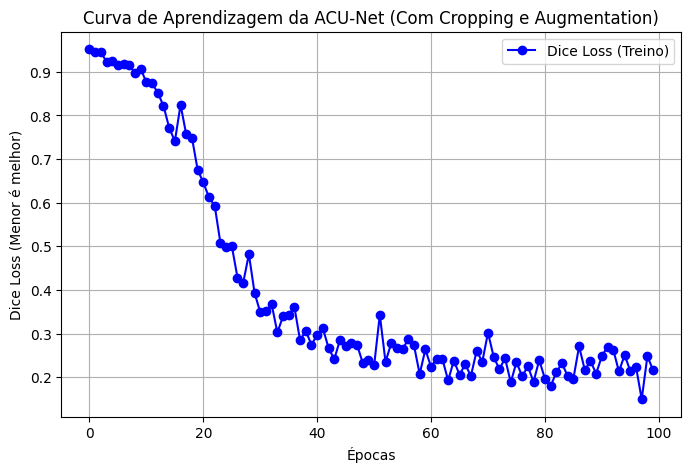

In [ ]:
# ==========================================
# EXECUÇÃO OFICIAL DO PROJETO
# ==========================================

def gerador_global_pacientes(lista_pacientes, tamanho_lote=8):
    """
    Gerador mestre: Sorteia um paciente, carrega na RAM, extrai fatias 2.5D,
    aplica Data Augmentation, Recorte (Cropping) e converte para PyTorch.
    """
    while True:
        np.random.shuffle(lista_pacientes)
        for paciente_path in lista_pacientes:
            try:
                # 1. Carrega o paciente inteiro na RAM (H, W, D, C)
                X_pac, Y_pac = processar_paciente_sob_demanda(paciente_path)

                # 2. Cria o gerador 2.5D local apenas para as fatias deste paciente
                gerador_fatias = gerador_lotes_2_5D(X_pac, Y_pac, tamanho_lote=tamanho_lote)

                # 3. Extrai lotes deste paciente
                lotes_por_paciente = 5
                for _ in range(lotes_por_paciente):
                    batch_x, batch_y = next(gerador_fatias)

                    # --- ELO PERDIDO 1: DATA AUGMENTATION ---
                    # Aplica transformações estocásticas (espelhamento/ruído)
                    batch_x_aug, batch_y_aug = aplicar_aumento_lote(batch_x, batch_y)

                    # 4. Transpõe os eixos para o padrão do modelo ACU-Net no PyTorch
                    batch_x_pt = np.transpose(batch_x_aug, (0, 3, 1, 2))
                    batch_y_pt = np.transpose(batch_y_aug, (0, 3, 1, 2))

                    # --- ELO PERDIDO 2: RECORTE ANATÔMICO (CROPPING) ---
                    # Reduz o excesso de fundo preto (ar) para focar no cérebro e economizar memória
                    batch_x_crop, batch_y_crop = recortar_centro_cerebro(
                        batch_x_pt, batch_y_pt, novo_tamanho=(160, 192)
                    )

                    yield torch.tensor(batch_x_crop, dtype=torch.float32), torch.tensor(batch_y_crop, dtype=torch.float32)
            except Exception as e:
                print(f"Aviso: Erro ao processar paciente {paciente_path}: {e}")
                continue

# 1. Instanciamos o modelo ACU-Net
modelo_acu = ACUNet(in_channels=12, out_channels=3)

# 2. Criamos o Gerador de Treino Global usando apenas os pacientes de treino
print("Preparando o Gerador Global sob demanda com Cropping e Augmentation...")
gerador_treino_global = gerador_global_pacientes(pacientes_treino, tamanho_lote=8)

# 3. Iniciamos o Treinamento!
print("\nIniciando Treinamento Oficial (Loop Mestre)...")
modelo_treinado, historico_treino = treinar_modelo(
    modelo=modelo_acu,
    gerador_treino=gerador_treino_global,
    passos_por_epoca=100,  # DICA: Para valer, aumente para 50 ou 100
    epocas=100,             # DICA: Para valer, aumente para 30 ou mais
    lr=5e-5
)

# 4. Plotamos a Curva de Aprendizagem Visual
plt.figure(figsize=(8, 5))
plt.plot(historico_treino, marker='o', color='b', label='Dice Loss (Treino)')
plt.title("Curva de Aprendizagem da ACU-Net (Com Cropping e Augmentation)")
plt.xlabel("Épocas")
plt.ylabel("Dice Loss (Menor é melhor)")
plt.grid(True)
plt.legend()
plt.show()


## 9. Avaliação Visual (Inferência)

Vamos pegar um paciente aleatório do dataset, extrair uma fatia e comparar a máscara real desenhada pelo médico com a predição da nossa ACU-Net recém-treinada.

1. Escolhe um paciente da validação
2. Carrega as 4 ressonâncias e a máscara real dele
3. Procura uma fatia que realmente tenha tumor
4. Prepara a imagem do mesmo jeito que no treino
5. Pede para a ACU-Net prever o tumor
6. Compara a previsão com a máscara médica

Testando inferência no paciente inédito: BraTS20_Training_348
Formato do X_teste_tensor: torch.Size([1, 12, 160, 192])
Dice Score Geral (3 Classes): 79.76%


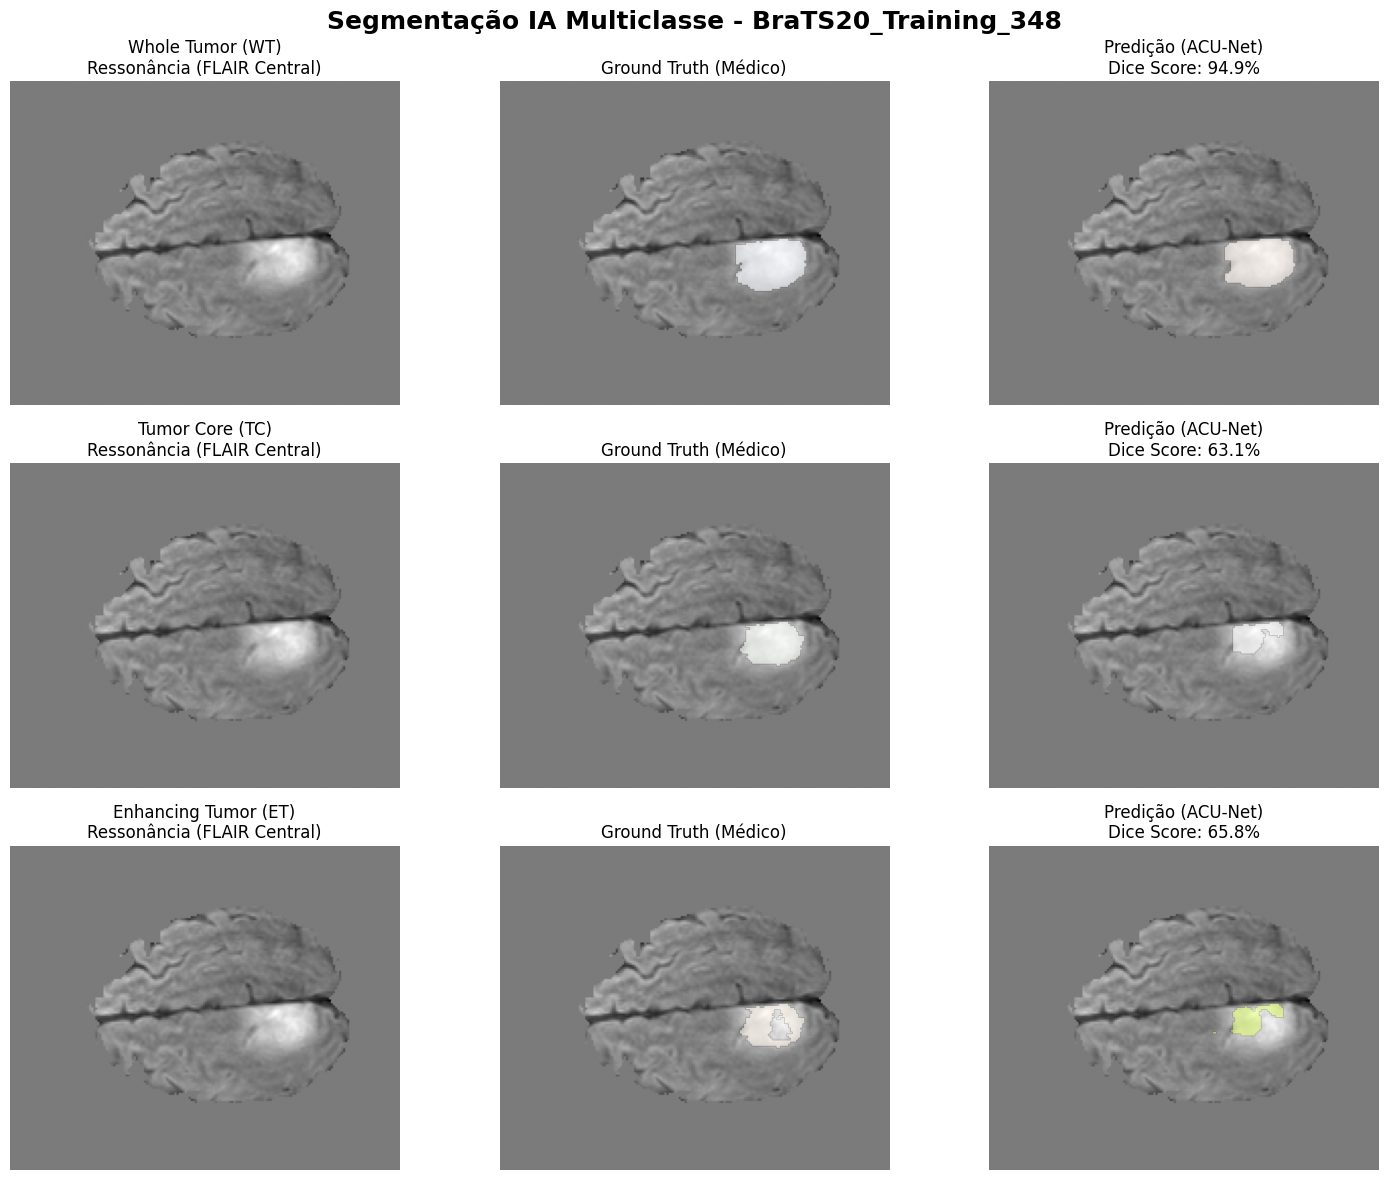

In [ ]:
import random
import matplotlib.pyplot as plt
import torch
import numpy as np
import os

# 1. Escolher 1 paciente de forma aleatória do conjunto de VALIDAÇÃO (Sem Data Leakage)
paciente_teste = random.choice(pacientes_validacao)
print(f"Testando inferência no paciente inédito: {os.path.basename(paciente_teste)}")

# 2. Processar paciente na RAM
X_bruto, Y_bruto = processar_paciente_sob_demanda(paciente_teste)

# 3. Usar nosso gerador diretamente com os dados originais (H, W, D, C)
gerador_teste_unico = gerador_lotes_2_5D(X_bruto, Y_bruto, tamanho_lote=1)

# Vamos procurar uma fatia que realmente tenha tumor (para não plotar uma tela preta)
tem_tumor = False
while not tem_tumor:
    lote_X_teste, lote_Y_teste = next(gerador_teste_unico)
    # Se a soma dos pixels do tumor for maior que 100, achamos uma fatia boa!
    if lote_Y_teste.sum() > 100:
        tem_tumor = True

# Transpor os eixos para o padrão do modelo ACU-Net no PyTorch: (Batch, Canais, H, W)
lote_X_pt = np.transpose(lote_X_teste, (0, 3, 1, 2))
lote_Y_pt = np.transpose(lote_Y_teste, (0, 3, 1, 2))

# Aplicar o mesmo recorte anatômico (Cropping) usado no treinamento
lote_X_crop, lote_Y_crop = recortar_centro_cerebro(
    lote_X_pt, lote_Y_pt, novo_tamanho=(160, 192)
)

# 4. Converter as saídas NumPy processadas para Tensores PyTorch
# Atenção: Garantir que device está definido
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_teste_tensor = torch.tensor(lote_X_crop, dtype=torch.float32).to(device)
Y_teste_tensor = torch.tensor(lote_Y_crop, dtype=torch.float32).to(device)
print(f"Formato do X_teste_tensor: {X_teste_tensor.shape}")

# A) Coloque o modelo em modo de avaliação
modelo_treinado.eval()

# B) Desligue o cálculo de gradientes
with torch.no_grad():
    logits_preditos = modelo_treinado(X_teste_tensor)

    # Aplicar Sigmoid para ter probabilidades e binarizar com limiar de 0.5
    probabilidades = torch.sigmoid(logits_preditos)
    mascara_predita = (probabilidades > 0.5).float()

    # Calcular Dice Score Geral (3 Classes)
    intersecao = (mascara_predita * Y_teste_tensor).sum()
    dice_score = (2. * intersecao) / (mascara_predita.sum() + Y_teste_tensor.sum() + 1e-6)
    print(f"Dice Score Geral (3 Classes): {dice_score.item() * 100:.2f}%")

# =====================================================================
# PREPARAÇÃO PARA PLOTAGEM MATPLOTLIB (AS 3 CLASSES)
# =====================================================================
# Voltar tensores para CPU e converter para NumPy
mascara_predita_np = mascara_predita.cpu().numpy()[0] # Shape: (3, 160, 192)
mascara_real_np = Y_teste_tensor.cpu().numpy()[0]     # Shape: (3, 160, 192)

# O eixo de canais agora é o índice 1!
# O bloco 2.5D tem 12 canais (0 a 11). A fatia central do FLAIR costuma estar no canal 7.
imagem_fundo_np = X_teste_tensor.cpu().numpy()[0, 7, :, :]

nomes_classes = ['Whole Tumor (WT)', 'Tumor Core (TC)', 'Enhancing Tumor (ET)']
cores_real = ['Blues', 'Greens', 'Oranges']
cores_pred = ['Reds', 'Purples', 'Wistia']

fig, eixos = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle(f"Segmentação IA Multiclasse - {os.path.basename(paciente_teste)}", fontsize=18, fontweight='bold')

for c in range(3):
    # Dice Score específico da classe 'c'
    intersecao_c = (mascara_predita_np[c] * mascara_real_np[c]).sum()
    dice_c = (2. * intersecao_c) / (mascara_predita_np[c].sum() + mascara_real_np[c].sum() + 1e-6)

    # Coluna 0: Ressonância (Fundo)
    eixos[c, 0].imshow(imagem_fundo_np, cmap='gray')
    eixos[c, 0].set_title(f'{nomes_classes[c]}\nRessonância (FLAIR Central)')
    eixos[c, 0].axis('off')

    # Coluna 1: Ground Truth (Médico)
    eixos[c, 1].imshow(imagem_fundo_np, cmap='gray')
    eixos[c, 1].imshow(np.ma.masked_where(mascara_real_np[c] == 0, mascara_real_np[c]), cmap=cores_real[c], alpha=0.6)
    eixos[c, 1].set_title('Ground Truth (Médico)')
    eixos[c, 1].axis('off')

    # Coluna 2: Predição (IA)
    eixos[c, 2].imshow(imagem_fundo_np, cmap='gray')
    eixos[c, 2].imshow(np.ma.masked_where(mascara_predita_np[c] == 0, mascara_predita_np[c]), cmap=cores_pred[c], alpha=0.6)
    eixos[c, 2].set_title(f'Predição (ACU-Net)\nDice Score: {dice_c * 100:.1f}%')
    eixos[c, 2].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Ajuste para o título principal não sobrepor
plt.show()

## 10. Avaliação Quantitativa: Matriz de Confusão

Diferente da classificação de imagens inteiras (ex: Cão vs. Gato), a segmentação médica avalia o acerto **píxel a píxel**.

Abaixo, achatamos os resultados da fatia testada em um único vetor para gerar uma Matriz de Confusão focada na classe **Whole Tumor (WT)**. A discrepância monstruosa entre a quantidade de tecido saudável (fundo escuro) e a massa tumoral ilustra perfeitamente o desbalanceamento típico de imagens médicas.

Gerando as Matrizes de Confusão para as 3 Classes...


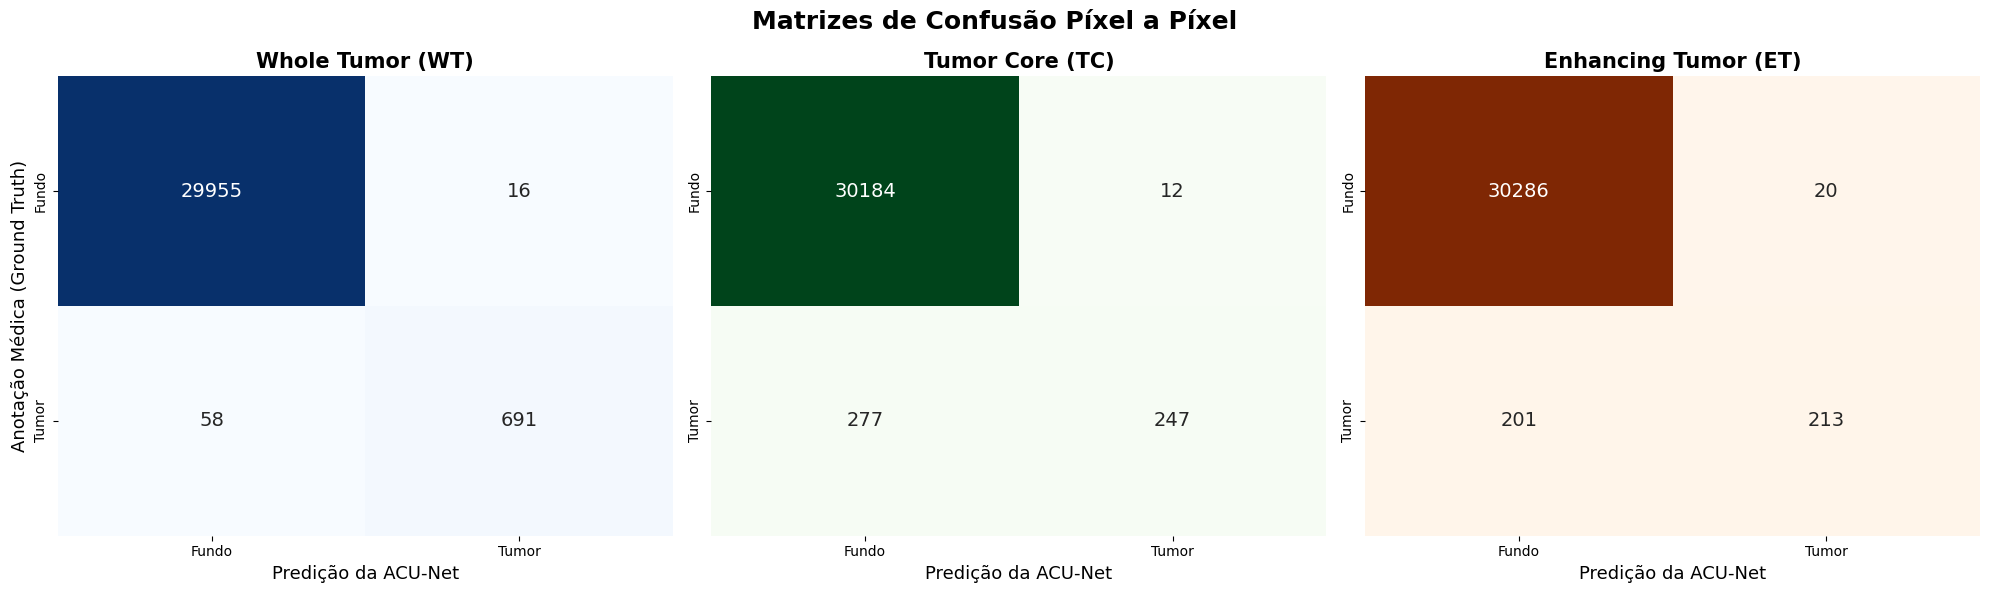

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# 10. MATRIZ DE CONFUSÃO (3 CLASSES)
# =====================================================================

print("Gerando as Matrizes de Confusão para as 3 Classes...")

fig, eixos = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Matrizes de Confusão Píxel a Píxel", fontsize=18, fontweight='bold')

nomes_classes = ['Whole Tumor (WT)', 'Tumor Core (TC)', 'Enhancing Tumor (ET)']
cores_heatmap = ['Blues', 'Greens', 'Oranges']

# Vamos armazenar as matrizes para usar na próxima célula matemática
matrizes_confusao = []

for c in range(3):
    # O .flatten() transforma a imagem 2D em uma lista 1D de pixels
    y_real_flat = mascara_real_np[c].flatten()
    y_pred_flat = mascara_predita_np[c].flatten()

    # Calcula a matriz forçando labels 0 e 1 para manter o formato 2x2 mesmo que não haja tumor na fatia
    cm = confusion_matrix(y_real_flat, y_pred_flat, labels=[0, 1])
    matrizes_confusao.append(cm)

    # 'fmt="d"' formata os números como inteiros exatos
    sns.heatmap(cm, annot=True, fmt="d", cmap=cores_heatmap[c], cbar=False,
                xticklabels=['Fundo', 'Tumor'],
                yticklabels=['Fundo', 'Tumor'],
                annot_kws={"size": 14}, ax=eixos[c])

    eixos[c].set_title(f"{nomes_classes[c]}", fontsize=15, fontweight='bold')
    eixos[c].set_xlabel("Predição da ACU-Net", fontsize=13)
    if c == 0:
        eixos[c].set_ylabel("Anotação Médica (Ground Truth)", fontsize=13)

plt.tight_layout()
plt.show()


### 10.1 Entendendo a Matemática do Dice Score
Os números flutuam a cada execução porque **testamos um paciente aleatório novo** toda vez. O mais importante é entender como a IA é avaliada. A matriz acima divide os pixels em quatro grupos:

- **Verdadeiros Negativos (Top-Left):** Pixels saudáveis corretamente ignorados. É sempre um número gigante, pois o cérebro tem muito tecido normal.
- **Verdadeiros Positivos (Bottom-Right):** Pixels de tumor que a IA acertou.
- **Falsos Positivos (Top-Right):** A IA "alucinou" tumor onde havia tecido saudável (Alarme Falso).
- **Falsos Negativos (Bottom-Left):** A IA falhou em detectar parte do tumor real.

Para calcular a precisão (Dice Score), a medicina **ignora os Verdadeiros Negativos**. O foco é penalizar os erros estritamente em torno da área da doença.

In [ ]:
import pandas as pd

# Calculando o Dice Score manualmente a partir das Matrizes de Confusão geradas
print("--- DISSECANDO A MATEMÁTICA DAS MATRIZES ---")

metricas = []

for c in range(3):
    cm = matrizes_confusao[c]
    TN = cm[0, 0] # Verdadeiros Negativos (Fundo Saudável Correto)
    FP = cm[0, 1] # Falsos Positivos (Alarme falso da IA)
    FN = cm[1, 0] # Falsos Negativos (Tumor que a IA perdeu)
    TP = cm[1, 1] # Verdadeiros Positivos (Acertos no tumor)

    # Fórmula do Coeficiente Dice:
    # 2 vezes a interseção (TP) dividido pela soma das áreas (que equivale a 2TP + FP + FN)
    dice_manual = (2 * TP) / (2 * TP + FP + FN + 1e-6)

    metricas.append({
        "Classe": nomes_classes[c],
        "TP (Acertos)": TP,
        "FP (Alarme Falso)": FP,
        "FN (Perdidos)": FN,
        "TN (Fundo Correto)": TN,
        "Dice Score (%)": round(dice_manual * 100, 2)
    })

# Exibir a tabela de forma bonita
df_metricas = pd.DataFrame(metricas)
display(df_metricas)

print("\n--- CONCLUSÕES CLÍNICAS ---")
print("1. O Dice Score é calculado de forma independente para cada estrutura tumoral: Dice = (2 * TP) / (2 * TP + FP + FN)")
print("2. Note como o 'TN (Fundo Correto)' possui valores gigantescos, pois a maior parte da imagem é composta por ar e cérebro saudável.")
print("3. É exatamente por isso que o Dice Score ignora os Verdadeiros Negativos (TN). Se a métrica avaliasse a 'Acurácia Global' considerando o fundo, a IA sempre pontuaria >99% de acerto apenas por adivinhar que a imagem inteira é escura, mascarando possíveis falhas clínicas graves no tumor (Falsos Negativos).")


--- DISSECANDO A MATEMÁTICA DAS MATRIZES ---


,Classe,TP (Acertos),FP (Alarme Falso),FN (Perdidos),TN (Fundo Correto),Dice Score (%)
0,Whole Tumor (WT),691,16,58,29955,94.92
1,Tumor Core (TC),247,12,277,30184,63.09
2,Enhancing Tumor (ET),213,20,201,30286,65.84



--- CONCLUSÕES CLÍNICAS ---
1. O Dice Score é calculado de forma independente para cada estrutura tumoral: Dice = (2 * TP) / (2 * TP + FP + FN)
2. Note como o 'TN (Fundo Correto)' possui valores gigantescos, pois a maior parte da imagem é composta por ar e cérebro saudável.
3. É exatamente por isso que o Dice Score ignora os Verdadeiros Negativos (TN). Se a métrica avaliasse a 'Acurácia Global' considerando o fundo, a IA sempre pontuaria >99% de acerto apenas por adivinhar que a imagem inteira é escura, mascarando possíveis falhas clínicas graves no tumor (Falsos Negativos).


## 11. Conclusão

#### 1. Quais dados são inseridos?
- **A População:** Utilizamos **579 pacientes reais** diagnosticados com Glioblastoma, combinando os bancos de dados do BraTS 2018 e BraTS 2020.
- **O Input Inicial:** De cada paciente, extraímos o cérebro escaneado em 4 modalidades magnéticas diferentes: **T1, T1CE, T2 e FLAIR**.
- **O Alvo (Ground Truth):** A máscara desenhada por especialistas humanos, decodificada em 3 regiões de interesse: **WT (Tumor Completo), TC (Núcleo) e ET (Realce Ativo)**.

#### 2. O Carregamento Sob Demanda (Estratégia de Memória)
Como 579 ressonâncias 3D ocupariam dezenas de Gigabytes e estourariam a RAM do Google Colab, nossa função `gerador_global_pacientes` é programada para ser "preguiçosa" (Lazy Loading):
- O gerador sorteia uma lista aleatória dos 579 pacientes a cada Época.
- Ele puxa **um paciente de cada vez** do disco para a RAM.
- Aplica a Correção **Z-Score (Brain-Only)** instantaneamente para normalizar os tons de cinza.

#### 3. A Mágica do 2.5D e o Data Augmentation
Com um paciente na RAM, não enviamos o cérebro inteiro para a placa de vídeo. Usamos o gerador para criar fatias:
- O algoritmo olha para uma fatia do tumor (fatia Z), mas pega a fatia debaixo (Z-1) e a de cima (Z+1). Como cada fatia tem 4 modalidades, empilhamos isso gerando um "bloco" hiper-denso de **12 canais**.
- **Mutação em Tempo Real:** Antes desse bloco ir para a rede, jogamos uma moeda (50% de chance). Podemos espelhar a imagem ou injetar estática (Ruído Gaussiano). Isso impede a rede de apenas memorizar a foto.
- **Cropping (Recorte):** Cortamos o fundo preto inútil ao redor do crânio, reduzindo a matriz geométrica de `240x240` para `160x192`. Isso faz o código rodar absurdamente mais rápido.

#### 4. O Coração da ACU-Net e a Otimização
- **Forward Pass:** O lote (Batch) de cérebros mutados (160x192 com 12 canais) entra na ACU-Net. Ela processa as texturas no *Encoder* e os *Attention Gates* gritam para a rede: "Ignore o cérebro saudável, olhe apenas para essa massa aqui!".
- **O Juiz (Dice Loss):** A rede expele uma tentativa de desenho do tumor. O `DiceLoss` compara a sobreposição matemática entre o desenho da rede e a máscara dos médicos.
- **A Aprendizagem:** O erro é passado para o otimizador **Adam**, que ajusta os milhões de pequenos pesos sinápticos do modelo na direção oposta ao erro (Backpropagation).

E esse ciclo se repetiu em lotes de 8 imagens, dezenas de vezes por época, até que a predição caótica se transformou em uma segmentação médica altamente precisa.

## Apêndice: Inspeção Direta do Gerador de Treino (Sanity Check)
Para termos certeza absoluta de que o pipeline de processamento está alimentando a rede neural corretamente, este bloco atua como uma **Auditoria Visual Final**. Ele intercepta um lote exato (Batch) que acabou de ser cuspido pelo `gerador_treino_global`, um milissegundo antes de entrar na ACU-Net.

**O que estamos validando rigorosamente aqui:**
1. **Geometria dos Tensores (Shapes):** Garantir que o tensor de entrada (X) possui os exatos 12 canais (2.5D) e que a máscara (Y) possui 3 canais, ambos com a dimensão espacial recortada (160x192).
2. **Binarização Estrita:** Confirmar que a máscara alvo (Ground Truth) contém estritamente os valores `0.0` (tecido saudável/fundo) e `1.0` (tumor), o que é vital para o cálculo correto da *Dice Loss*.
3. **Normalização Z-Score:** Verificar se a distribuição estatística das imagens médicas originais (T1, T1CE, FLAIR) está centralizada próxima a 0.
4. **Desconstrução Lógica (One-Hot Encoding):** Provar visualmente que a máscara original com valores 1, 2 e 4 foi fatiada corretamente nos 3 mapas binários independentes (WT, TC e ET).

Extraindo um lote do gerador global...

Shape de Entrada (X_batch): torch.Size([8, 12, 160, 192]) -> (Lote, 12 Canais, Altura, Largura)
Shape do Alvo (Y_batch): torch.Size([8, 3, 160, 192]) -> (Lote, 3 Classes, Altura, Largura)
Min/Max da Máscara: 0.0 / 1.0 -> (Confirma que são apenas 0s e 1s binários)



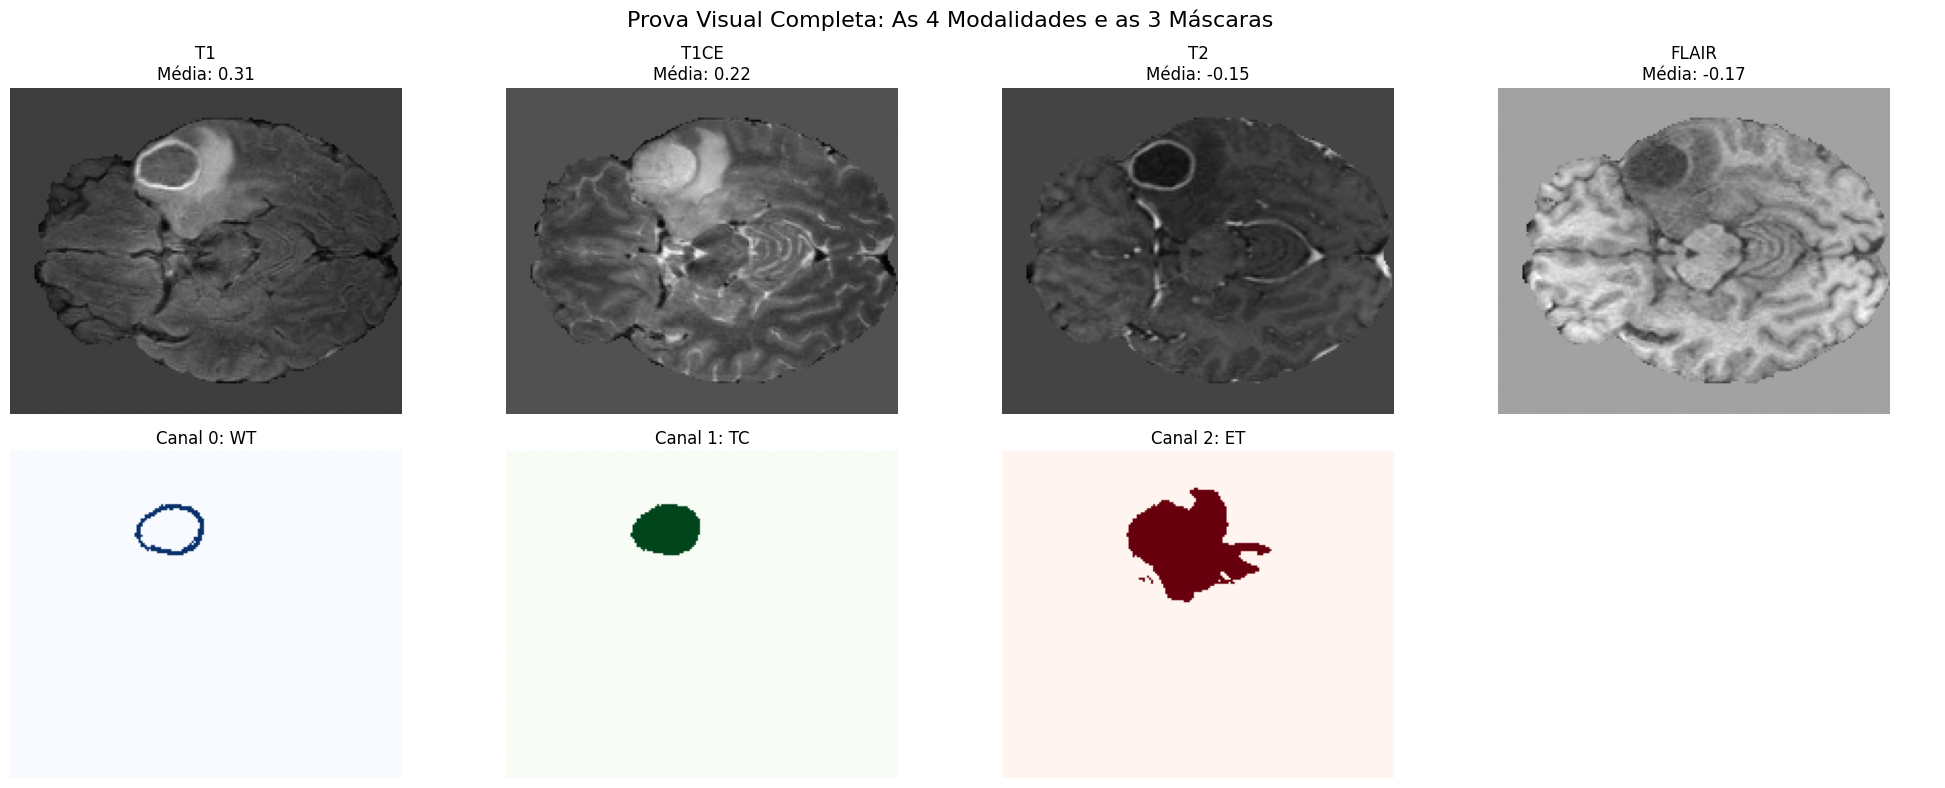

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extração direta de um lote do gerador de treino
print("Extraindo um lote do gerador global...")
X_batch, Y_batch = next(gerador_treino_global)

# Converter os tensores PyTorch do primeiro elemento do lote para NumPy
x_np = X_batch[0].numpy()
y_np = Y_batch[0].numpy()

print(f"\nShape de Entrada (X_batch): {X_batch.shape} -> (Lote, 12 Canais, Altura, Largura)")
print(f"Shape do Alvo (Y_batch): {Y_batch.shape} -> (Lote, 3 Classes, Altura, Largura)")
print(f"Min/Max da Máscara: {y_np.min()} / {y_np.max()} -> (Confirma que são apenas 0s e 1s binários)\n")

# Mudei para 2 linhas e 4 colunas!
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Prova Visual Completa: As 4 Modalidades e as 3 Máscaras", fontsize=16)

# --- LINHA 1: NORMALIZAÇÃO (Modalidades da Fatia Central Z) ---
axes[0, 0].imshow(x_np[4], cmap='gray')
axes[0, 0].set_title(f"T1\nMédia: {x_np[4].mean():.2f}")

axes[0, 1].imshow(x_np[5], cmap='gray')
axes[0, 1].set_title(f"T1CE\nMédia: {x_np[5].mean():.2f}")

axes[0, 2].imshow(x_np[6], cmap='gray') # <-- O SEU T2 ESTÁ AQUI!
axes[0, 2].set_title(f"T2\nMédia: {x_np[6].mean():.2f}")

axes[0, 3].imshow(x_np[7], cmap='gray')
axes[0, 3].set_title(f"FLAIR\nMédia: {x_np[7].mean():.2f}")

# --- LINHA 2: MÁSCARAS DESCONSTRUÍDAS ---
axes[1, 0].imshow(y_np[0], cmap='Blues')
axes[1, 0].set_title("Canal 0: WT")

axes[1, 1].imshow(y_np[1], cmap='Greens')
axes[1, 1].set_title("Canal 1: TC")

axes[1, 2].imshow(y_np[2], cmap='Reds')
axes[1, 2].set_title("Canal 2: ET")

# O último espaço (axes[1, 3]) fica vazio, podemos desligá-lo
axes[1, 3].axis('off')

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

## 12. Garantia de Reprodutibilidade
Para que outros pesquisadores (ou você mesmo no futuro) consigam obter os mesmos resultados deste notebook, é fundamental fixar as sementes aleatórias (seeds) e documentar as versões exatas do ambiente de software e hardware utilizado.

In [ ]:
import torch
import numpy as np
import random
import sys
import nibabel as nib
import SimpleITK as sitk

# 1. Fixar Seeds para inicialização determinística
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Se estiver usando GPU, forçar o determinismo do cuDNN
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 2. Documentar o Ambiente (Exibir para o Relatório)
print("="*50)
print(" RELATÓRIO DE AMBIENTE E REPRODUTIBILIDADE ")
print("="*50)
print(f"Semente Aleatória Fixada (Seed) : {SEED}")
print(f"Versão Python                   : {sys.version.split()[0]}")
print(f"Versão PyTorch                  : {torch.__version__}")
print(f"Versão NumPy                    : {np.__version__}")
print(f"Versão NiBabel                  : {nib.__version__}")
print(f"Versão SimpleITK                : {sitk.__version__}")

print("-"*50)
if torch.cuda.is_available():
    print(f"Hardware Acelerador (GPU)       : {torch.cuda.get_device_name(0)}")
else:
    print("Hardware Acelerador (GPU)       : NENHUMA GPU DETECTADA (Treino em CPU)")
print("="*50)

# Opcional: Gerar arquivo requirements.txt com todas as dependências
!pip freeze > requirements.txt
print("\nArquivo 'requirements.txt' gerado com sucesso contendo todas as bibliotecas do Colab.")

 RELATÓRIO DE AMBIENTE E REPRODUTIBILIDADE 
Semente Aleatória Fixada (Seed) : 42
Versão Python                   : 3.12.13
Versão PyTorch                  : 2.11.0+cu128
Versão NumPy                    : 2.0.2
Versão NiBabel                  : 5.4.2
Versão SimpleITK                : 2.5.5
--------------------------------------------------
Hardware Acelerador (GPU)       : Tesla T4

Arquivo 'requirements.txt' gerado com sucesso contendo todas as bibliotecas do Colab.


In [ ]:
```python
# ==========================================================
# RELATÓRIO DE AMBIENTE E REPRODUTIBILIDADE
# ==========================================================

import sys
import os
import glob
import random
import platform
import subprocess
import importlib.metadata as metadata

import torch
import numpy as np
import nibabel as nib
import SimpleITK as sitk
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn

# ----------------------------------------------------------
# 1. FIXAR SEMENTES PARA REDUZIR ALEATORIEDADE
# ----------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

    # Busca maior consistência entre execuções
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Mantém o treino funcional mesmo se alguma operação
    # não tiver implementação totalmente determinística.
    torch.use_deterministic_algorithms(True, warn_only=True)

# ----------------------------------------------------------
# 2. FUNÇÃO PARA OBTER VERSÕES COM SEGURANÇA
# ----------------------------------------------------------

def obter_versao(nome_pacote):
    """
    Retorna a versão instalada de um pacote.
    Caso não esteja disponível, retorna uma mensagem informativa.
    """
    try:
        return metadata.version(nome_pacote)
    except metadata.PackageNotFoundError:
        return "Não instalado / versão não localizada"
    except Exception as erro:
        return f"Erro ao consultar: {erro}"

# ----------------------------------------------------------
# 3. DETECÇÃO DO AMBIENTE GOOGLE COLAB
# ----------------------------------------------------------

try:
    import google.colab
    ambiente_colab = "Sim"
    versao_colab = obter_versao("google-colab")
except ImportError:
    ambiente_colab = "Não"
    versao_colab = "Não disponível fora do Google Colab"

try:
    import kaggle
    versao_kaggle = obter_versao("kaggle")
except ImportError:
    versao_kaggle = "Kaggle API não instalada"

# ----------------------------------------------------------
# 4. EXIBIR RELATÓRIO
# ----------------------------------------------------------

print("=" * 65)
print(" RELATÓRIO DE AMBIENTE E REPRODUTIBILIDADE")
print("=" * 65)

print("\n[CONFIGURAÇÃO DE REPRODUTIBILIDADE]")
print(f"Seed fixa utilizada              : {SEED}")
print(f"Algoritmos determinísticos       : Ativados quando possível")

print("\n[SISTEMA E AMBIENTE]")
print(f"Python                           : {sys.version.split()[0]}")
print(f"Sistema operacional              : {platform.platform()}")
print(f"Executando no Google Colab       : {ambiente_colab}")
print(f"Pacote google-colab              : {versao_colab}")

print("\n[BIBLIOTECAS PRINCIPAIS]")
print(f"PyTorch                          : {torch.__version__}")
print(f"NumPy                            : {np.__version__}")
print(f"NiBabel                          : {nib.__version__}")
print(f"SimpleITK                        : {obter_versao('SimpleITK')}")
print(f"Matplotlib                       : {matplotlib.__version__}")
print(f"Pandas                           : {pd.__version__}")
print(f"Seaborn                          : {sns.__version__}")
print(f"Scikit-learn                     : {sklearn.__version__}")
print(f"Kaggle API                       : {versao_kaggle}")

print("\n[BIBLIOTECAS NATIVAS DO PYTHON]")
print(f"os                               : Biblioteca padrão do Python {sys.version.split()[0]}")
print(f"glob                             : Biblioteca padrão do Python {sys.version.split()[0]}")
print(f"random                           : Biblioteca padrão do Python {sys.version.split()[0]}")
print(f"sys                              : Biblioteca padrão do Python {sys.version.split()[0]}")

print("\n[GPU E CUDA]")
print(f"CUDA disponível                  : {torch.cuda.is_available()}")
print(f"Versão CUDA do PyTorch           : {torch.version.cuda}")
print(f"Versão cuDNN                     : {torch.backends.cudnn.version()}")

if torch.cuda.is_available():
    print(f"GPU utilizada                    : {torch.cuda.get_device_name(0)}")
    print(f"Quantidade de GPUs               : {torch.cuda.device_count()}")
else:
    print("GPU utilizada                    : Nenhuma GPU detectada; execução em CPU.")

print("=" * 65)

# ----------------------------------------------------------
# 5. GERAR REQUIREMENTS COMPLETO DO AMBIENTE
# ----------------------------------------------------------

subprocess.run(
    [sys.executable, "-m", "pip", "freeze"],
    stdout=open("requirements.txt", "w"),
    check=False
)

print("\nArquivo 'requirements.txt' gerado com todas as bibliotecas instaladas.")

# ----------------------------------------------------------
# 6. GERAR REQUIREMENTS APENAS DO PROJETO
# ----------------------------------------------------------

pacotes_projeto = {
    "torch": obter_versao("torch"),
    "numpy": obter_versao("numpy"),
    "nibabel": obter_versao("nibabel"),
    "SimpleITK": obter_versao("SimpleITK"),
    "matplotlib": obter_versao("matplotlib"),
    "pandas": obter_versao("pandas"),
    "seaborn": obter_versao("seaborn"),
    "scikit-learn": obter_versao("scikit-learn"),
    "kaggle": obter_versao("kaggle"),
}

with open("requirements_projeto.txt", "w", encoding="utf-8") as arquivo:
    for pacote, versao in pacotes_projeto.items():
        if "Não instalado" not in versao and "Erro" not in versao:
            arquivo.write(f"{pacote}=={versao}\n")

print("Arquivo 'requirements_projeto.txt' gerado com as dependências do projeto.")
```
